# Projet Deep Learning - Version 1

## 1.Importation des packages

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
#import umap

torch.manual_seed(0)

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print('Device utilisé :', device)

Device utilisé : mps


## 2.Importation

In [2]:
#Chargement des données
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

## 3.Préparation des données

### 3.1 Configuration d'apprentissage

In [3]:
#Configuration d'apprentissage
CONFIG = {
    'BATCH_SIZE': 32,
    'EPOCHS': 100,
    'LR': 1e-3
}

### 3.2 Préparation des données

In [4]:
#Préparation des données
X_train = train.drop('Activity', axis=1).values
y_train = train['Activity'].values
X_test = test.drop('Activity', axis=1).values
y_test = test['Activity'].values

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#Create tensors
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train, dtype=torch.long, device=device)
X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test, dtype=torch.long, device=device)

#Create dataset
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

#Create data loader with batchs
trainloader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
testloader  = DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True)

## 4.Modèle et fonction d'entraînement

### 4.1 Modèle

In [5]:
class ActivityClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, activation, p_dropout=0.0, use_batchnorm=True):
        super().__init__()

        layers = []
        prev_dim = input_dim
        
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation)
            if p_dropout > 0:
                layers.append(nn.Dropout(p_dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


### 4.2 Fonction train_epoch

In [6]:
def train_epoch(model, loader, optimizer, lossfn, device):
    model.train()
    training_loss = 0.0
    training_acc = 0
    total = 0
    
    all_preds = []
    all_labels = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        loss = lossfn(logits, y)
        loss.backward()
        optimizer.step()

        # Accumuler la perte et l'accuracy
        training_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        training_acc += (preds == y).sum().item()
        total += x.size(0)

        # Stocker les prédictions et labels pour calcul du F1
        all_preds.append(preds.detach().cpu())
        all_labels.append(y.detach().cpu())

    # Concaténer toutes les prédictions / labels
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Calcul du F1
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_per_class = f1_score(all_labels, all_preds, average=None)

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)

    # Retourner les métriques
    return training_loss / total, training_acc / total, f1_macro, f1_per_class, cm 


### 4.3 Fonction evaluate

In [7]:
def evaluate(model, loader, lossfn, device):
    model.eval()
    test_loss = 0.0
    test_acc = 0
    total = 0
    all_preds = [] 
    all_labels = []

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)

            logits = model(x)
            loss = lossfn(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            test_acc += (preds==y).sum().item()
            total += x.size(0)

            # Stocker les prédictions et labels pour calcul du F1
            all_preds.append(preds.detach().cpu())
            all_labels.append(y.detach().cpu())

    # Concaténer toutes les prédictions / labels
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Calcul du F1
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_per_class = f1_score(all_labels, all_preds, average=None)

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)

    return test_loss/total, test_acc/total, f1_macro, f1_per_class, cm

### 4.4 Fonction compute_train_history

In [8]:
def compute_train_history(mlp, trainloader, testloader, optimizer, lossfn, device, epochs, early_stopping=False, patience=10, save_path='best_mlp_model.pth'):
    history_mlp = {"epoch": [], 'train_loss':[], 'train_acc':[], 'train_f1_macro': [],  'train_f1_per_class': [], 'train_cm': [],  'test_loss':[], 'test_acc':[],'test_f1_macro': [], 'test_f1_per_class': [], 'test_cm': []}
    best_test_loss = float("inf")
    patience_counter = 0
    for epoch in range(1, epochs + 1):
        history_mlp["epoch"].append(epoch)
        # TODO : Compléter la boucle d'entraînement et d'évaluation du modèle MLP
        train_loss, train_acc, train_f1_macro, train_f1_per_class, train_cm = train_epoch(mlp, trainloader, optimizer, lossfn, device)
    
        history_mlp["train_loss"].append(train_loss)
        history_mlp["train_acc"].append(train_acc)
        history_mlp["train_f1_macro"].append(train_f1_macro)
        history_mlp["train_f1_per_class"].append(train_f1_per_class)
        history_mlp["train_cm"].append(train_cm)

        test_loss, test_acc, test_f1_macro, test_f1_per_class, test_cm = evaluate(mlp, testloader, lossfn, device)

        history_mlp["test_loss"].append(test_loss)
        history_mlp["test_acc"].append(test_acc)
        history_mlp["test_f1_macro"].append(test_f1_macro)
        history_mlp["test_f1_per_class"].append(test_f1_per_class)
        history_mlp["test_cm"].append(test_cm)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
        
        # === EARLY STOPPING ===
        if not early_stopping:
            continue
        else:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping activé : l'entraînement s'arrête.")
                break
    return history_mlp

### 4.5 Fonction plot_train_history

In [9]:
def plot_training_history(history_mlp, title_suffix=''):

    # --- FIGURE 1 : Train Loss ---
    figure, axes = plt.subplots(nrows=5, ncols=2, figsize=(15,10), sharex=True, sharey=False, constrained_layout=True)
    axes[0, 0].plot(history_mlp['train_loss'], label='MLP')
    axes[0, 0].set_title(" Train Loss -" + title_suffix)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # --- FIGURE 2 : Test Loss ---
    axes[0, 1].plot(history_mlp['test_loss'], label='MLP')
    axes[0, 1].set_title('Test Loss -' + title_suffix)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # --- FIGURE 3 : Train Accuracy ---
    axes[1, 0].plot(history_mlp['train_acc'], label='MLP')
    axes[1, 0].set_title(" Train Accuracy -" + title_suffix)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # --- FIGURE 4 : Test Accuracy ---
    axes[1, 1].plot(history_mlp['test_acc'], label='MLP')
    axes[1, 1].set_title('Test Accuracy -' + title_suffix)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    # --- FIGURE 5 : Train F1 macro ---
    axes[2, 0].plot(history_mlp['train_f1_macro'], label='MLP')
    axes[2, 0].set_title(" Train F1 Macro -" + title_suffix)
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('F1 Score')
    axes[2, 0].legend()
    axes[2, 0].grid(True)

    # --- FIGURE 6 : Test F1 macro ---
    axes[2, 1].plot(history_mlp['test_f1_macro'], label='MLP')
    axes[2, 1].set_title('Test F1 Macro -' + title_suffix)
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].legend()
    axes[2, 1].grid(True)

    # --- FIGURE 7 : Train F1 per class ---
    sns.barplot(data=pd.DataFrame(history_mlp['train_f1_per_class']), ax=axes[3, 0])
    axes[3, 0].set_title(" Train F1 Per Class -" + title_suffix)
    axes[3, 0].set_xlabel('Class')
    axes[3, 0].set_ylabel('F1 Score')
    axes[3, 0].grid(True)

    # --- FIGURE 8 : Test F1 per class ---
    sns.barplot(data=pd.DataFrame(history_mlp['test_f1_per_class']), ax=axes[3, 1])
    axes[3, 1].set_title(" Test F1 Per Class -" + title_suffix)
    axes[3, 1].set_xlabel('Class')
    axes[3, 1].grid(True)

    # --- FIGURE 9 : Train CM ---
    sns.heatmap(data=history_mlp['train_cm'][-1], ax=axes[4, 0], annot=True, fmt="d", cmap="Blues")
    axes[4, 0].set_title(" Train CM -" + title_suffix)
    axes[4, 0].set_xlabel('Class')
    axes[4, 0].set_ylabel('CM')
    axes[4, 0].grid(True)

    # --- FIGURE 10 : Test CM ---
    sns.heatmap(data=history_mlp['test_cm'][-1], ax=axes[4, 1], annot=True, fmt="d", cmap="Blues")
    axes[4, 1].set_title(" Test CM -" + title_suffix)
    axes[4, 1].set_xlabel('Class')
    axes[4, 1].grid(True)
    plt.show()

## 5.Boucle d'entraînement

Les modèles ci-dessous sont entrainés avec 2 couches cachées

### 5.1 Apprentissage avec RELU

1. Activation: RELU
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

In [10]:
# --- Modèle 5.1 --
mlp_5_1= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_5_1 = mlp_5_1.to(device)
optimizer = torch.optim.Adam(mlp_5_1.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 5.1)")
history_mlp_5_1 = compute_train_history(mlp_5_1, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])

==> Entraînement du modèle MLP avec ReLU (Modèle 5.1)
Epoch 10/100 - Train Loss: 0.0618, Train Acc: 0.9762, Test Loss: 0.1426, Test Acc: 0.9555
Epoch 20/100 - Train Loss: 0.0283, Train Acc: 0.9899, Test Loss: 0.1742, Test Acc: 0.9552
Epoch 30/100 - Train Loss: 0.0177, Train Acc: 0.9931, Test Loss: 0.1958, Test Acc: 0.9494
Epoch 40/100 - Train Loss: 0.0130, Train Acc: 0.9955, Test Loss: 0.2796, Test Acc: 0.9372
Epoch 50/100 - Train Loss: 0.0124, Train Acc: 0.9950, Test Loss: 0.1926, Test Acc: 0.9600
Epoch 60/100 - Train Loss: 0.0120, Train Acc: 0.9973, Test Loss: 0.1817, Test Acc: 0.9613
Epoch 70/100 - Train Loss: 0.0084, Train Acc: 0.9959, Test Loss: 0.2403, Test Acc: 0.9528
Epoch 80/100 - Train Loss: 0.0110, Train Acc: 0.9965, Test Loss: 0.2447, Test Acc: 0.9542
Epoch 90/100 - Train Loss: 0.0053, Train Acc: 0.9980, Test Loss: 0.2296, Test Acc: 0.9576
Epoch 100/100 - Train Loss: 0.0069, Train Acc: 0.9980, Test Loss: 0.2020, Test Acc: 0.9623


### 5.2 Apprentissage avec Sigmoïd

1. Activation: Sigmoïd
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

In [11]:
# --- Modèle 5.2 --
mlp_5_2= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[128, 64], num_classes=len(le.classes_), activation=nn.Sigmoid())
mlp_5_2 = mlp_5_2.to(device)
optimizer = torch.optim.Adam(mlp_5_2.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec Sigmoid (Modèle 5.2)")
history_mlp_5_2 = compute_train_history(mlp_5_2, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])

==> Entraînement du modèle MLP avec Sigmoid (Modèle 5.2)
Epoch 10/100 - Train Loss: 0.0631, Train Acc: 0.9784, Test Loss: 0.1531, Test Acc: 0.9498
Epoch 20/100 - Train Loss: 0.0462, Train Acc: 0.9833, Test Loss: 0.1215, Test Acc: 0.9572
Epoch 30/100 - Train Loss: 0.0337, Train Acc: 0.9874, Test Loss: 0.1548, Test Acc: 0.9477
Epoch 40/100 - Train Loss: 0.0215, Train Acc: 0.9920, Test Loss: 0.1969, Test Acc: 0.9450
Epoch 50/100 - Train Loss: 0.0128, Train Acc: 0.9965, Test Loss: 0.1846, Test Acc: 0.9511
Epoch 60/100 - Train Loss: 0.0172, Train Acc: 0.9936, Test Loss: 0.2163, Test Acc: 0.9450
Epoch 70/100 - Train Loss: 0.0064, Train Acc: 0.9982, Test Loss: 0.1665, Test Acc: 0.9579
Epoch 80/100 - Train Loss: 0.0119, Train Acc: 0.9958, Test Loss: 0.1657, Test Acc: 0.9549
Epoch 90/100 - Train Loss: 0.0125, Train Acc: 0.9967, Test Loss: 0.2371, Test Acc: 0.9532
Epoch 100/100 - Train Loss: 0.0050, Train Acc: 0.9984, Test Loss: 0.1883, Test Acc: 0.9555


### 5.3 Apprentissage avec Tanh

1. Activation: Tanh
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

In [12]:
# --- Modèle 5.3 --
mlp_5_3= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[128, 64], num_classes=len(le.classes_), activation=nn.Tanh())
mlp_5_3 = mlp_5_3.to(device)
optimizer = torch.optim.Adam(mlp_5_3.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec Tanh (Modèle 5.3)")
history_mlp_5_3 = compute_train_history(mlp_5_3, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])

==> Entraînement du modèle MLP avec Tanh (Modèle 5.3)
Epoch 10/100 - Train Loss: 0.0557, Train Acc: 0.9774, Test Loss: 0.1856, Test Acc: 0.9369
Epoch 20/100 - Train Loss: 0.0313, Train Acc: 0.9898, Test Loss: 0.1973, Test Acc: 0.9382
Epoch 30/100 - Train Loss: 0.0274, Train Acc: 0.9899, Test Loss: 0.1559, Test Acc: 0.9569
Epoch 40/100 - Train Loss: 0.0124, Train Acc: 0.9958, Test Loss: 0.2077, Test Acc: 0.9494
Epoch 50/100 - Train Loss: 0.0078, Train Acc: 0.9976, Test Loss: 0.2299, Test Acc: 0.9467
Epoch 60/100 - Train Loss: 0.0070, Train Acc: 0.9976, Test Loss: 0.1723, Test Acc: 0.9552
Epoch 70/100 - Train Loss: 0.0139, Train Acc: 0.9950, Test Loss: 0.2210, Test Acc: 0.9532
Epoch 80/100 - Train Loss: 0.0086, Train Acc: 0.9967, Test Loss: 0.2303, Test Acc: 0.9508
Epoch 90/100 - Train Loss: 0.0082, Train Acc: 0.9976, Test Loss: 0.2875, Test Acc: 0.9467
Epoch 100/100 - Train Loss: 0.0054, Train Acc: 0.9986, Test Loss: 0.2507, Test Acc: 0.9505


### 5.4 Apprentissage avec SGD

1. Activation: RELU
2. Optimizer: SGD
3. Critère: nn.CrossEntropyLoss()

In [13]:
# --- Modèle 5.4 --
mlp_5_4= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_5_4 = mlp_5_4.to(device)
optimizer = torch.optim.SGD(mlp_5_4.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec SGD (Modèle 5.4)")
history_mlp_5_4 = compute_train_history(mlp_5_4, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])

==> Entraînement du modèle MLP avec SGD (Modèle 5.4)
Epoch 10/100 - Train Loss: 0.3104, Train Acc: 0.9363, Test Loss: 0.3083, Test Acc: 0.9355
Epoch 20/100 - Train Loss: 0.1626, Train Acc: 0.9655, Test Loss: 0.2021, Test Acc: 0.9471
Epoch 30/100 - Train Loss: 0.1123, Train Acc: 0.9737, Test Loss: 0.1804, Test Acc: 0.9460
Epoch 40/100 - Train Loss: 0.0855, Train Acc: 0.9808, Test Loss: 0.1615, Test Acc: 0.9511
Epoch 50/100 - Train Loss: 0.0719, Train Acc: 0.9844, Test Loss: 0.1482, Test Acc: 0.9528
Epoch 60/100 - Train Loss: 0.0583, Train Acc: 0.9876, Test Loss: 0.1469, Test Acc: 0.9511
Epoch 70/100 - Train Loss: 0.0501, Train Acc: 0.9890, Test Loss: 0.1614, Test Acc: 0.9450
Epoch 80/100 - Train Loss: 0.0446, Train Acc: 0.9914, Test Loss: 0.1404, Test Acc: 0.9545
Epoch 90/100 - Train Loss: 0.0342, Train Acc: 0.9937, Test Loss: 0.1411, Test Acc: 0.9545
Epoch 100/100 - Train Loss: 0.0328, Train Acc: 0.9943, Test Loss: 0.1378, Test Acc: 0.9545


### 5.5 Apprentissage avec SGD Momentum

1. Activation: RELU
2. Optimizer: SGD Momentum
3. Critère: nn.CrossEntropyLoss()

In [14]:
# --- Modèle 5.5 --
mlp_5_5= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_5_5 = mlp_5_5.to(device)
optimizer = torch.optim.SGD(mlp_5_5.parameters(), lr=CONFIG['LR'], momentum=0.9)
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec SGD avec Momentum (Modèle 5.5)")
history_mlp_5_5 = compute_train_history(mlp_5_5, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])

==> Entraînement du modèle MLP avec SGD avec Momentum (Modèle 5.5)
Epoch 10/100 - Train Loss: 0.0580, Train Acc: 0.9844, Test Loss: 0.1660, Test Acc: 0.9444
Epoch 20/100 - Train Loss: 0.0270, Train Acc: 0.9936, Test Loss: 0.1897, Test Acc: 0.9410
Epoch 30/100 - Train Loss: 0.0212, Train Acc: 0.9932, Test Loss: 0.2250, Test Acc: 0.9396
Epoch 40/100 - Train Loss: 0.0124, Train Acc: 0.9973, Test Loss: 0.1909, Test Acc: 0.9471
Epoch 50/100 - Train Loss: 0.0074, Train Acc: 0.9989, Test Loss: 0.1722, Test Acc: 0.9532
Epoch 60/100 - Train Loss: 0.0070, Train Acc: 0.9985, Test Loss: 0.1871, Test Acc: 0.9488
Epoch 70/100 - Train Loss: 0.0046, Train Acc: 0.9993, Test Loss: 0.1624, Test Acc: 0.9650
Epoch 80/100 - Train Loss: 0.0031, Train Acc: 0.9996, Test Loss: 0.1877, Test Acc: 0.9555
Epoch 90/100 - Train Loss: 0.0033, Train Acc: 0.9995, Test Loss: 0.1941, Test Acc: 0.9522
Epoch 100/100 - Train Loss: 0.0030, Train Acc: 0.9997, Test Loss: 0.1888, Test Acc: 0.9549


# 6. Visualisation des résultats

## 6.1 Loss

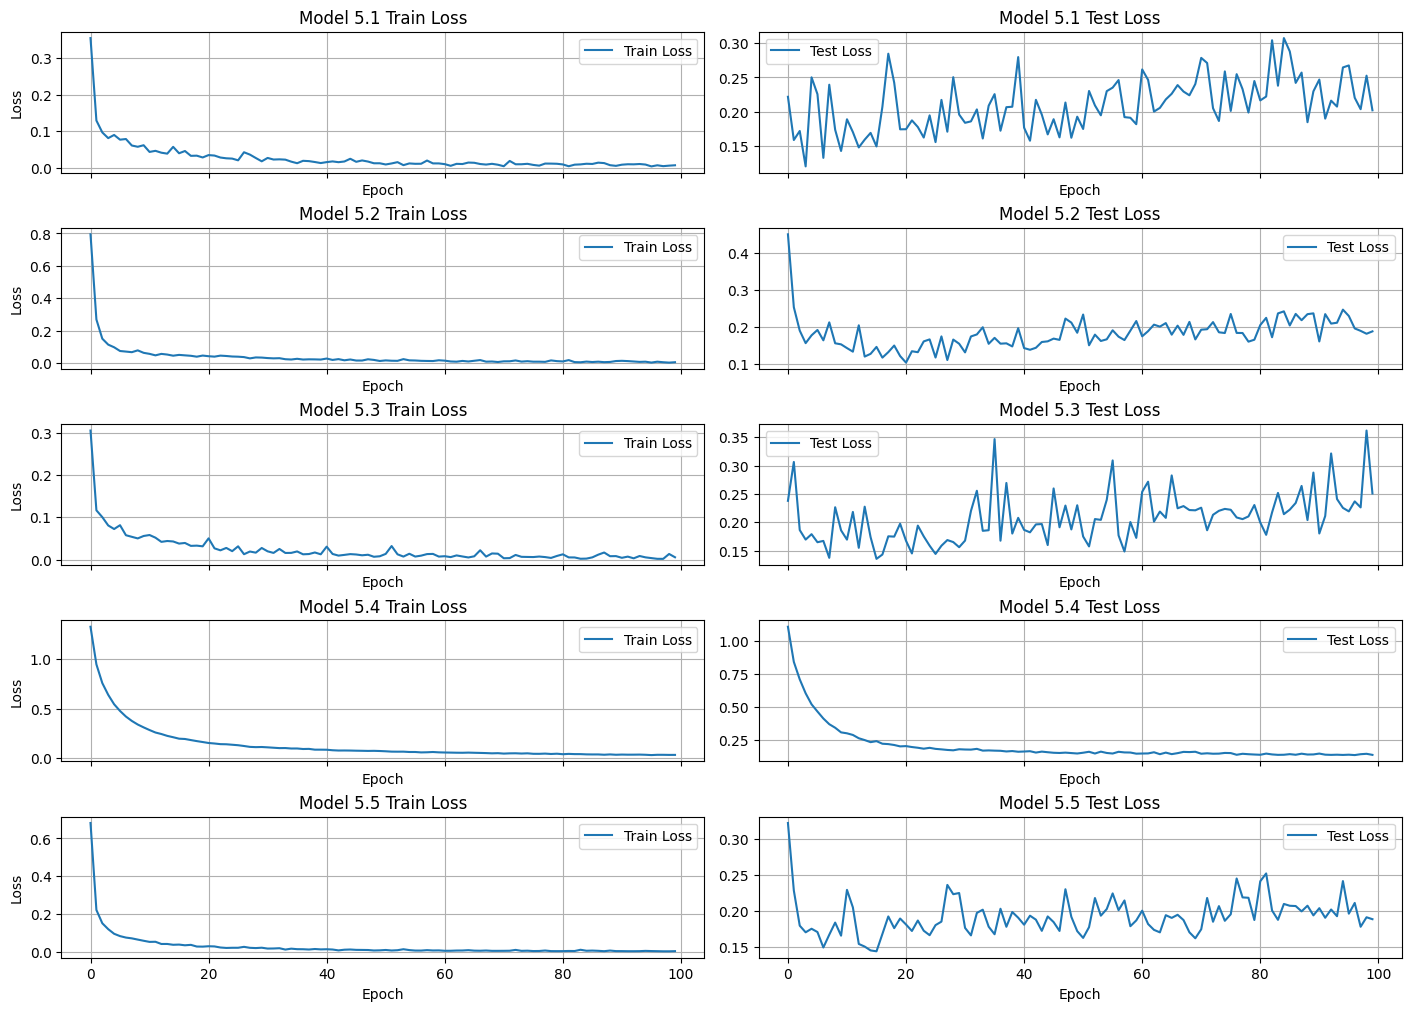

In [15]:
fig, axs = plt.subplots(5,2, figsize=(14, 10), sharex=True, sharey=False, constrained_layout=True)
for i, history in enumerate([history_mlp_5_1, history_mlp_5_2, history_mlp_5_3, history_mlp_5_4, history_mlp_5_5]):
    axs[i,0].plot(history['train_loss'], label='Train Loss')
    axs[i,0].set_title(f'Model 5.{i+1} Train Loss')
    axs[i,0].set_xlabel('Epoch')
    axs[i,0].set_ylabel('Loss')
    axs[i,0].legend()
    axs[i,0].grid(True)

    axs[i,1].plot(history['test_loss'], label='Test Loss')
    axs[i,1].set_title(f'Model 5.{i+1} Test Loss')
    axs[i,1].set_xlabel('Epoch')
    axs[i,1].legend()
    axs[i,1].grid(True)

## 6.2 Accuracy

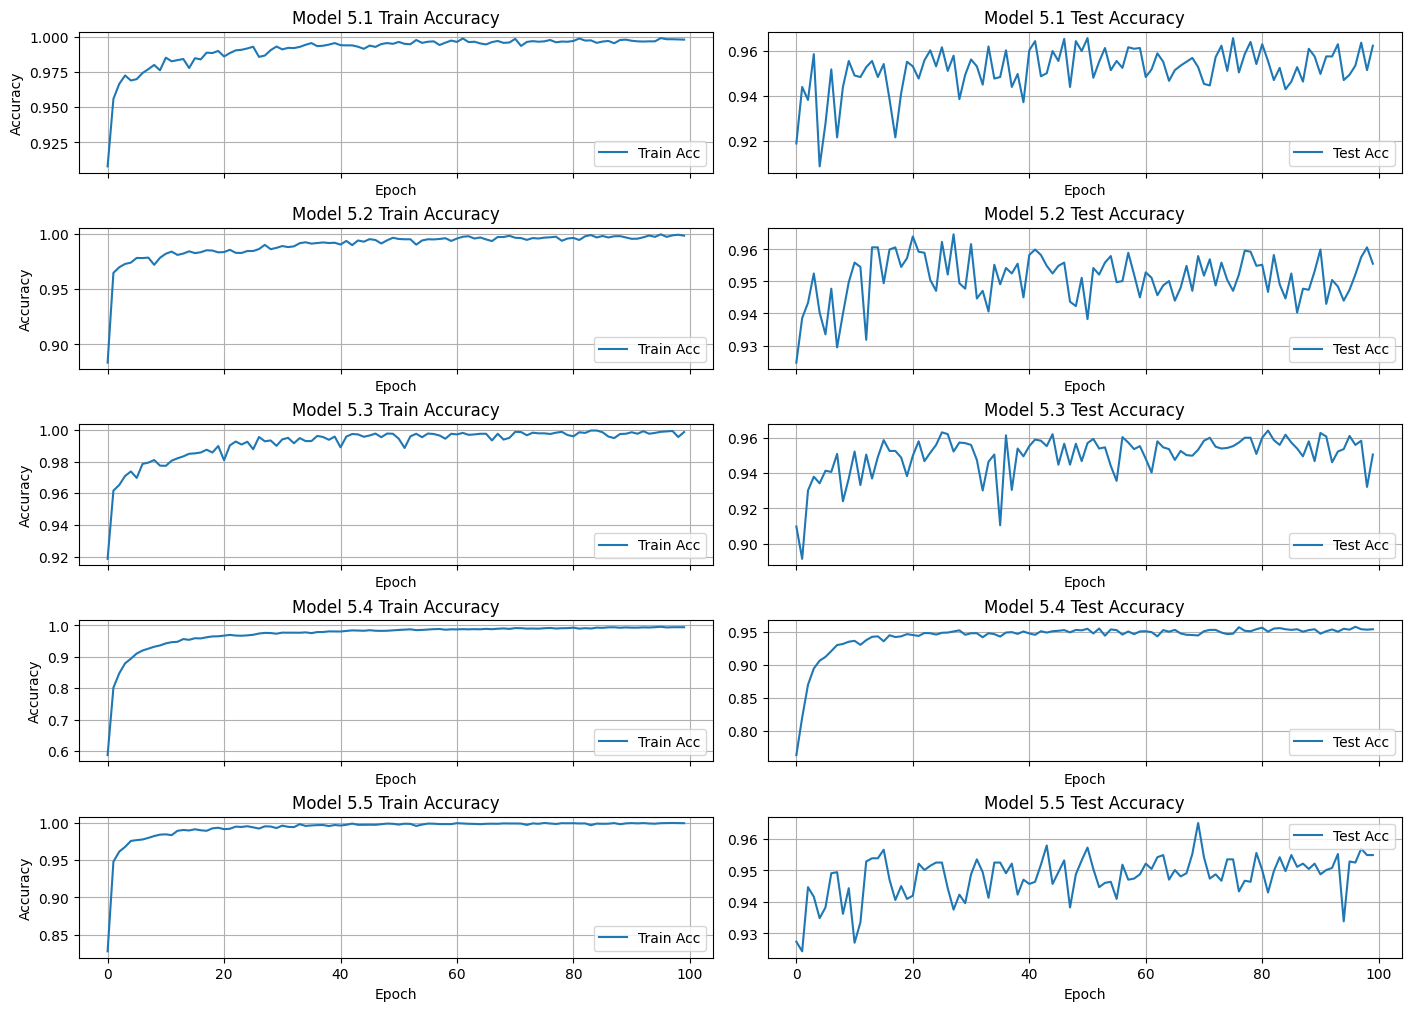

In [16]:
fig, axs = plt.subplots(5,2, figsize=(14, 10), sharex=True, sharey=False, constrained_layout=True)
for i, history in enumerate([history_mlp_5_1, history_mlp_5_2, history_mlp_5_3, history_mlp_5_4, history_mlp_5_5]):
    axs[i,0].plot(history['train_acc'], label='Train Acc')
    axs[i,0].set_title(f'Model 5.{i+1} Train Accuracy')
    axs[i,0].set_xlabel('Epoch')
    axs[i,0].set_ylabel('Accuracy')
    axs[i,0].legend()
    axs[i,0].grid(True)

    axs[i,1].plot(history['test_acc'], label='Test Acc')
    axs[i,1].set_title(f'Model 5.{i+1} Test Accuracy')
    axs[i,1].set_xlabel('Epoch')
    axs[i,1].legend()
    axs[i,1].grid(True)

## 6.3 F1-score

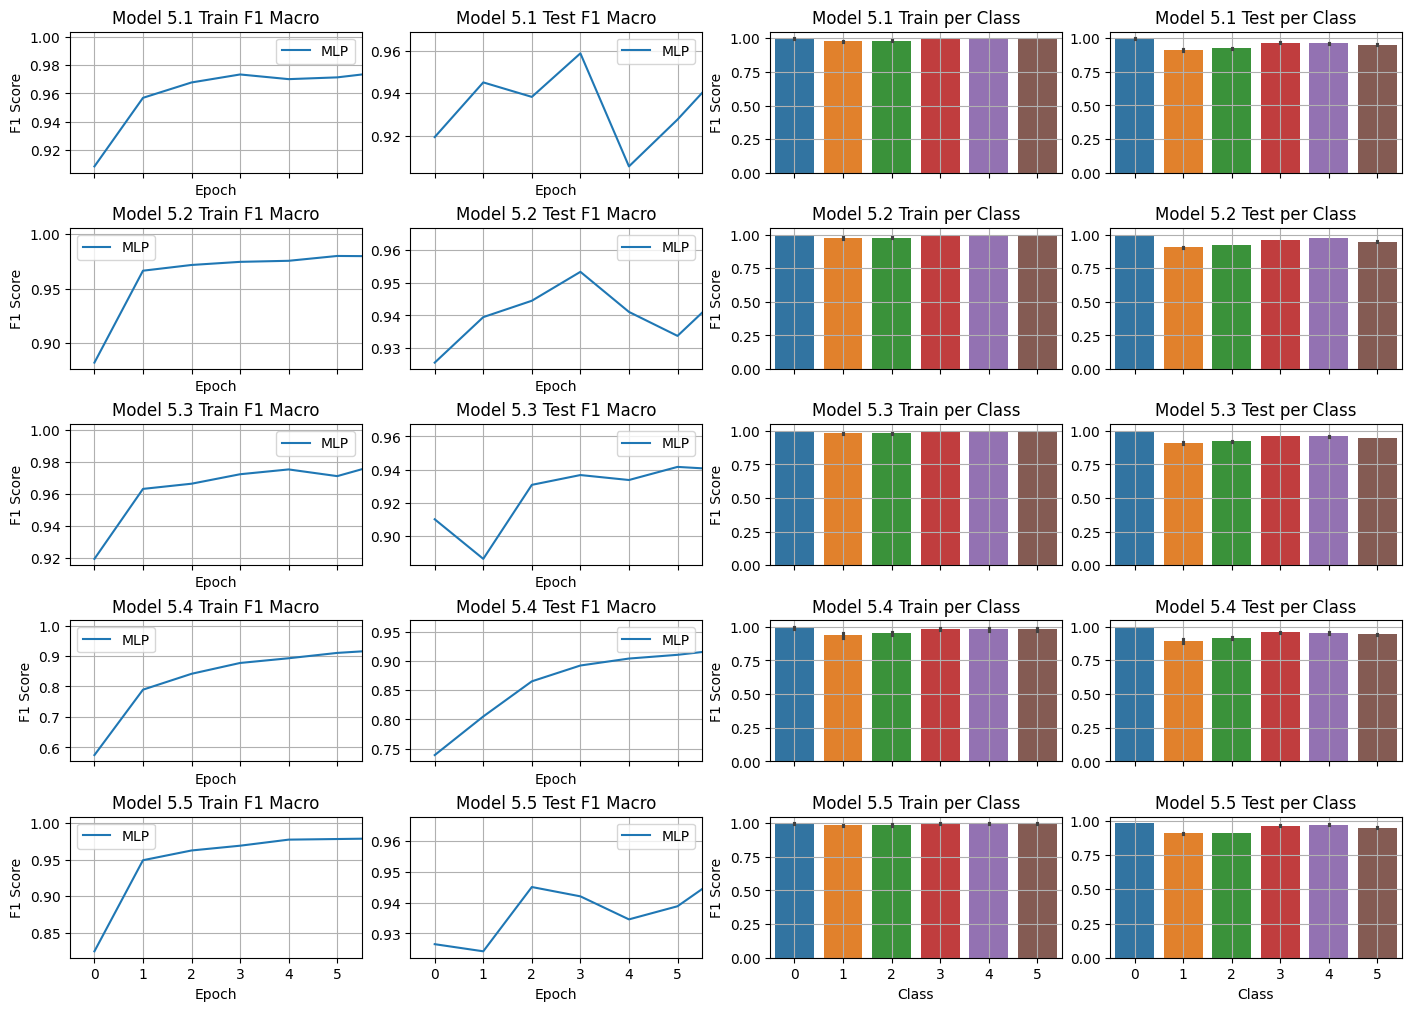

In [17]:
fig, axes = plt.subplots(5,4, figsize=(14, 10), sharex=True, sharey=False, constrained_layout=True)
for i, history in enumerate([history_mlp_5_1, history_mlp_5_2, history_mlp_5_3, history_mlp_5_4, history_mlp_5_5]):

    # --- FIGURE 3 : Train F1 macro ---
    axes[i, 0].plot(history['train_f1_macro'], label='MLP')
    axes[i, 0].set_title(f'Model 5.{i+1} Train F1 Macro')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('F1 Score')
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # --- FIGURE 4 : Test F1 macro ---
    axes[i, 1].plot(history['test_f1_macro'], label='MLP')
    axes[i, 1].set_title(f'Model 5.{i+1} Test F1 Macro')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

    # --- FIGURE 5 : Train F1 per class ---
    sns.barplot(data=pd.DataFrame(history['train_f1_per_class']), ax=axes[i, 2])
    axes[i, 2].set_title(f'Model 5.{i+1} Train per Class')
    axes[i, 2].set_xlabel('Class')
    axes[i, 2].set_ylabel('F1 Score')
    axes[i, 2].grid(True)

    # --- FIGURE 5 : Test F1 per class ---
    sns.barplot(data=pd.DataFrame(history['test_f1_per_class']), ax=axes[i, 3])
    axes[i, 3].set_title(f'Model 5.{i+1} Test per Class')
    axes[i, 3].set_xlabel('Class')
    axes[i, 3].grid(True)

## 6.4 Matrice de confusion

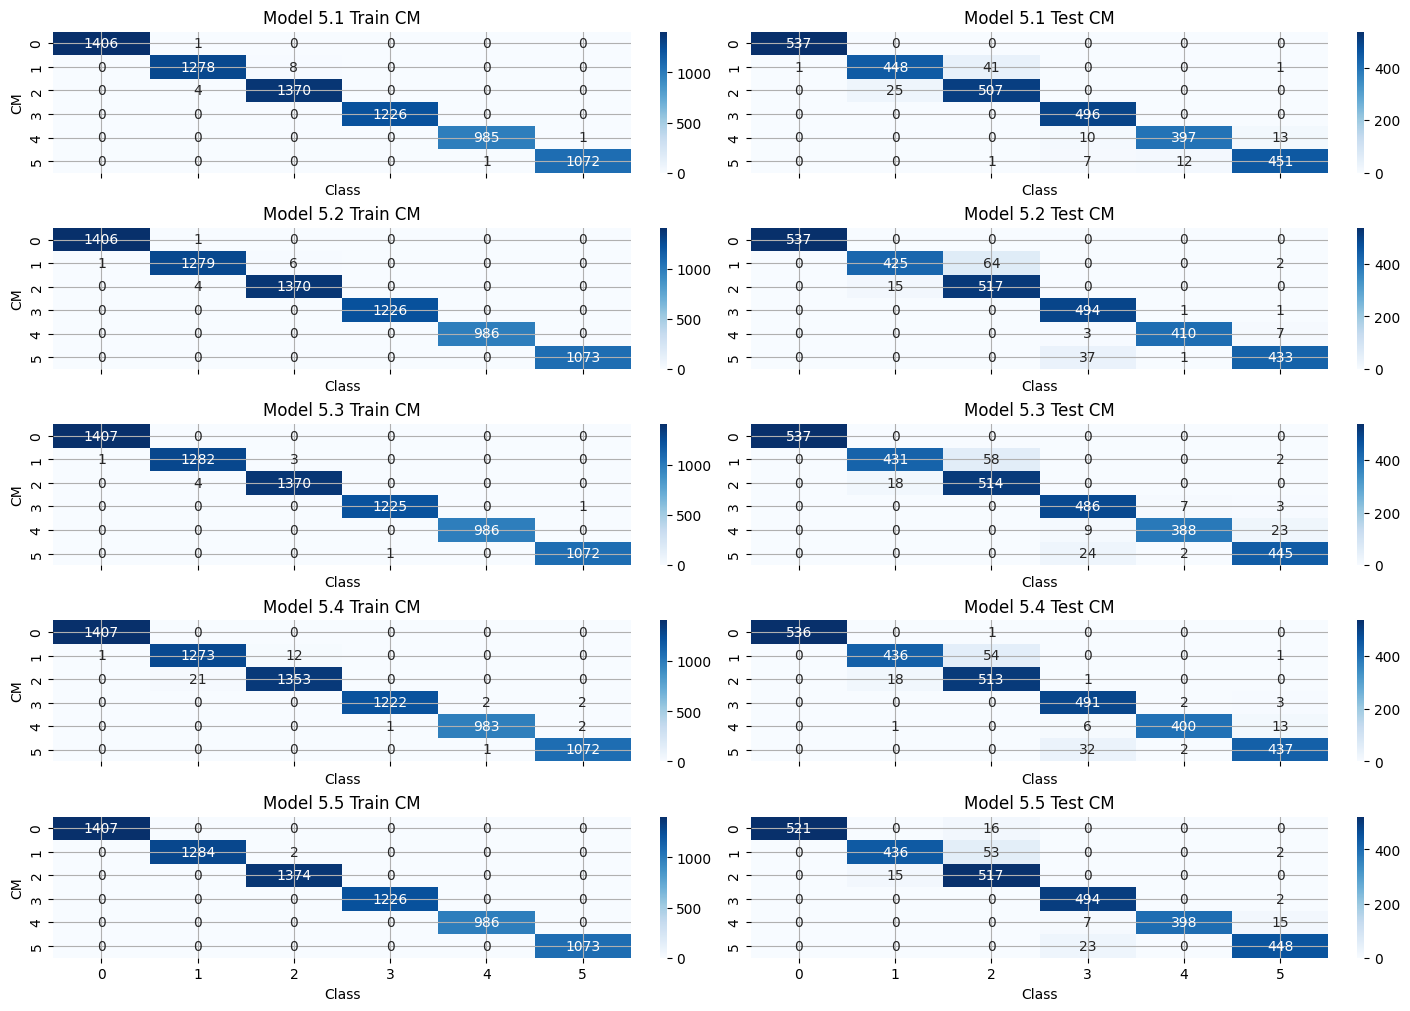

In [18]:
fig, axs = plt.subplots(5,2, figsize=(14, 10), sharex=True, sharey=False, constrained_layout=True)
for i, history in enumerate([history_mlp_5_1, history_mlp_5_2, history_mlp_5_3, history_mlp_5_4, history_mlp_5_5]):
    sns.heatmap(data=history['train_cm'][-1], ax=axs[i, 0], annot=True, fmt="d", cmap="Blues")
    axs[i,0].set_title(f'Model 5.{i+1} Train CM')
    axs[i,0].set_xlabel('Class')
    axs[i,0].set_ylabel('CM')
    axs[i,0].grid(True)

    sns.heatmap(data=history['test_cm'][-1], ax=axs[i, 1], annot=True, fmt="d", cmap="Blues")
    axs[i,1].set_title(f'Model 5.{i+1} Test CM')
    axs[i,1].set_xlabel('Class')
    axs[i,1].grid(True)

# 7. Nombre de couches cachées: 3 et 4

Apprentissage avec RELU et Adam

1. Activation: RELU
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

## 7.1 Nombre de couches cachées: 3

==> Entraînement du modèle MLP avec ReLU (Modèle 7.1)
Epoch 10/100 - Train Loss: 0.0733, Train Acc: 0.9742, Test Loss: 0.1526, Test Acc: 0.9488
Epoch 20/100 - Train Loss: 0.0386, Train Acc: 0.9857, Test Loss: 0.2111, Test Acc: 0.9440
Epoch 30/100 - Train Loss: 0.0368, Train Acc: 0.9872, Test Loss: 0.2329, Test Acc: 0.9437
Epoch 40/100 - Train Loss: 0.0204, Train Acc: 0.9922, Test Loss: 0.2054, Test Acc: 0.9559
Epoch 50/100 - Train Loss: 0.0142, Train Acc: 0.9956, Test Loss: 0.2633, Test Acc: 0.9372
Epoch 60/100 - Train Loss: 0.0116, Train Acc: 0.9965, Test Loss: 0.1955, Test Acc: 0.9583
Epoch 70/100 - Train Loss: 0.0162, Train Acc: 0.9942, Test Loss: 0.2146, Test Acc: 0.9589
Epoch 80/100 - Train Loss: 0.0087, Train Acc: 0.9977, Test Loss: 0.1859, Test Acc: 0.9603
Epoch 90/100 - Train Loss: 0.0111, Train Acc: 0.9956, Test Loss: 0.2003, Test Acc: 0.9620
Epoch 100/100 - Train Loss: 0.0062, Train Acc: 0.9973, Test Loss: 0.2079, Test Acc: 0.9586


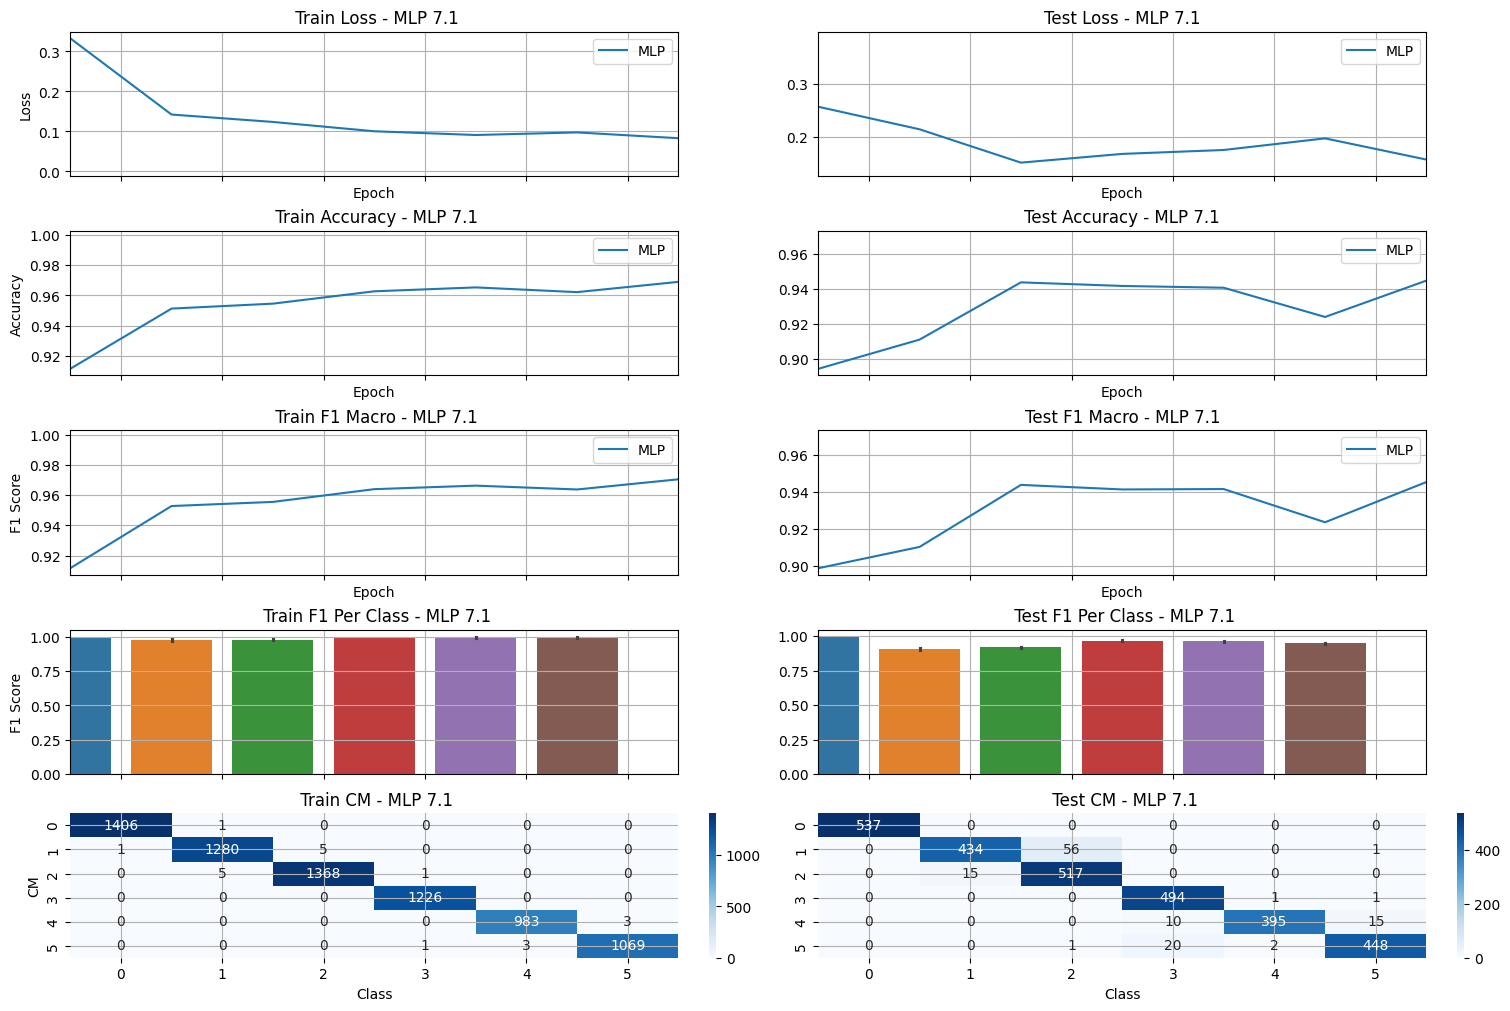

In [19]:
# --- Modèle 7.1 --
mlp_7_1= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_7_1 = mlp_7_1.to(device)
optimizer = torch.optim.Adam(mlp_7_1.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 7.1)")
history_mlp_7_1 = compute_train_history(mlp_7_1, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_7_1, title_suffix=' MLP 7.1')

## 7.2 Nombre de couches cachées: 4

==> Entraînement du modèle MLP avec ReLU (Modèle 7.2)
Epoch 10/100 - Train Loss: 0.0719, Train Acc: 0.9727, Test Loss: 0.1862, Test Acc: 0.9372
Epoch 20/100 - Train Loss: 0.0590, Train Acc: 0.9791, Test Loss: 0.1487, Test Acc: 0.9579
Epoch 30/100 - Train Loss: 0.0436, Train Acc: 0.9838, Test Loss: 0.1732, Test Acc: 0.9484
Epoch 40/100 - Train Loss: 0.0171, Train Acc: 0.9929, Test Loss: 0.1766, Test Acc: 0.9569
Epoch 50/100 - Train Loss: 0.0224, Train Acc: 0.9925, Test Loss: 0.2421, Test Acc: 0.9376
Epoch 60/100 - Train Loss: 0.0241, Train Acc: 0.9910, Test Loss: 0.1466, Test Acc: 0.9650
Epoch 70/100 - Train Loss: 0.0112, Train Acc: 0.9958, Test Loss: 0.1687, Test Acc: 0.9664
Epoch 80/100 - Train Loss: 0.0104, Train Acc: 0.9962, Test Loss: 0.2105, Test Acc: 0.9620
Epoch 90/100 - Train Loss: 0.0054, Train Acc: 0.9985, Test Loss: 0.2402, Test Acc: 0.9515
Epoch 100/100 - Train Loss: 0.0105, Train Acc: 0.9967, Test Loss: 0.2338, Test Acc: 0.9542


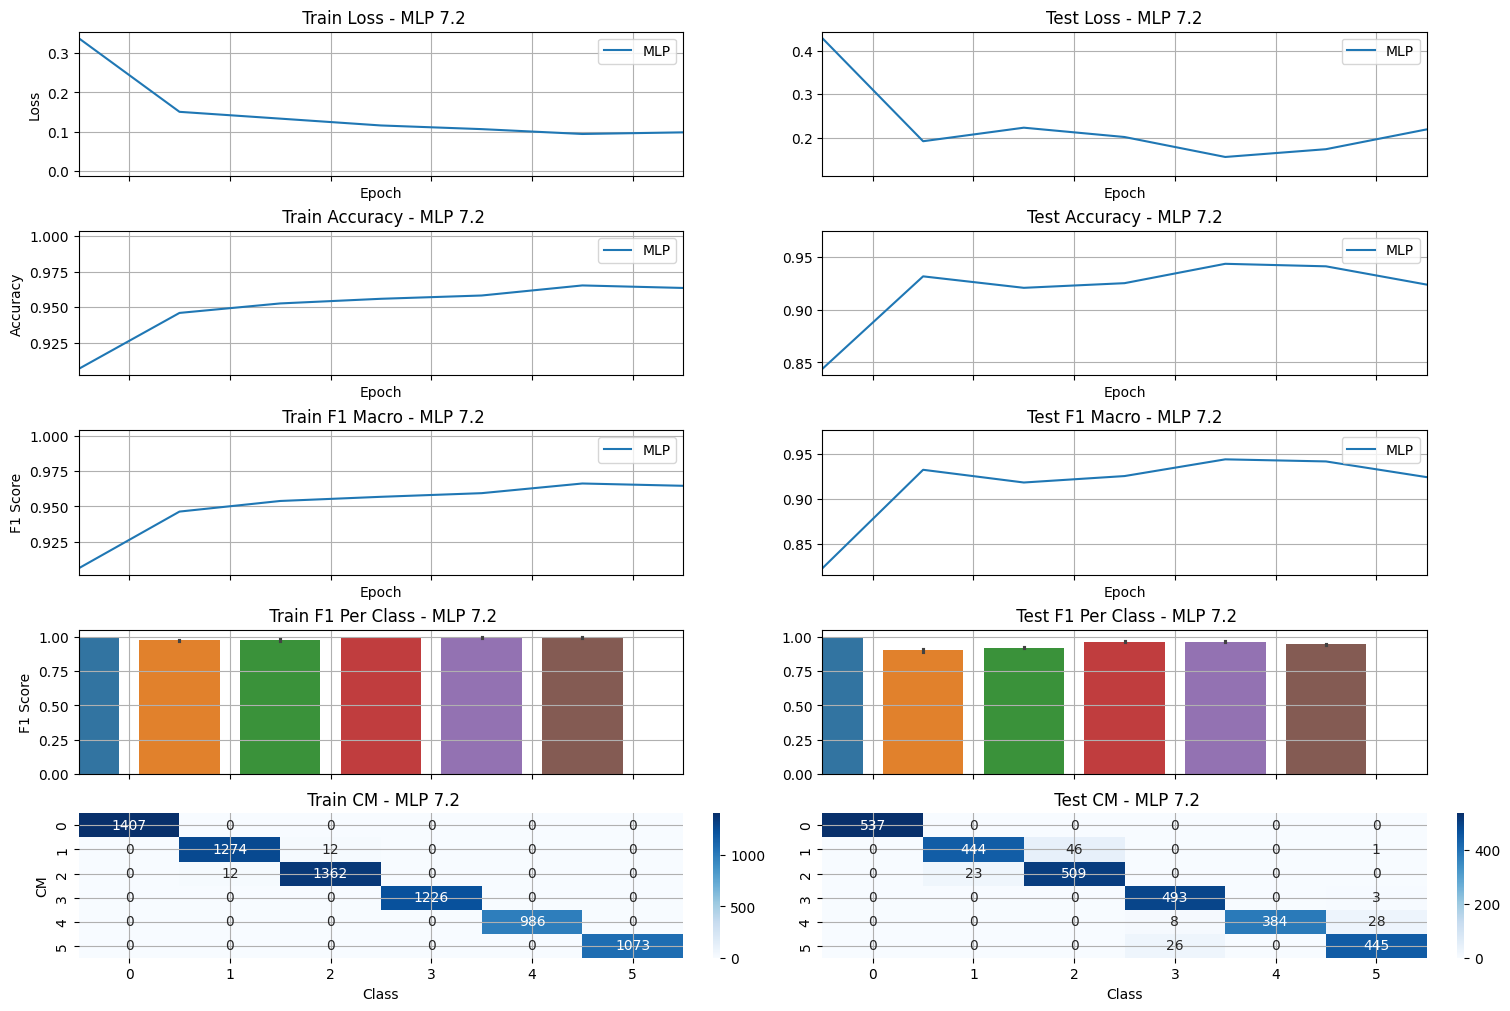

In [20]:
# --- Modèle 7.2 --
mlp_7_2= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_7_2 = mlp_7_2.to(device)
optimizer = torch.optim.Adam(mlp_7_2.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 7.2)")
history_mlp_7_2 = compute_train_history(mlp_7_2, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_7_2, title_suffix=' MLP 7.2')

# 8. Régularisation

## 8.1 Dropout

### 8.1.1 Dropout : 0.1

==> Entraînement du modèle MLP avec ReLU (Modèle 8.1.1)
Epoch 10/100 - Train Loss: 0.0697, Train Acc: 0.9737, Test Loss: 0.2240, Test Acc: 0.9291
Epoch 20/100 - Train Loss: 0.0553, Train Acc: 0.9793, Test Loss: 0.1827, Test Acc: 0.9481
Epoch 30/100 - Train Loss: 0.0429, Train Acc: 0.9833, Test Loss: 0.1709, Test Acc: 0.9528
Epoch 40/100 - Train Loss: 0.0289, Train Acc: 0.9897, Test Loss: 0.1876, Test Acc: 0.9501
Epoch 50/100 - Train Loss: 0.0276, Train Acc: 0.9895, Test Loss: 0.2242, Test Acc: 0.9501
Epoch 60/100 - Train Loss: 0.0233, Train Acc: 0.9913, Test Loss: 0.1654, Test Acc: 0.9650
Epoch 70/100 - Train Loss: 0.0229, Train Acc: 0.9920, Test Loss: 0.2021, Test Acc: 0.9522
Epoch 80/100 - Train Loss: 0.0189, Train Acc: 0.9937, Test Loss: 0.1832, Test Acc: 0.9610
Epoch 90/100 - Train Loss: 0.0155, Train Acc: 0.9952, Test Loss: 0.1930, Test Acc: 0.9572
Epoch 100/100 - Train Loss: 0.0091, Train Acc: 0.9969, Test Loss: 0.1877, Test Acc: 0.9593


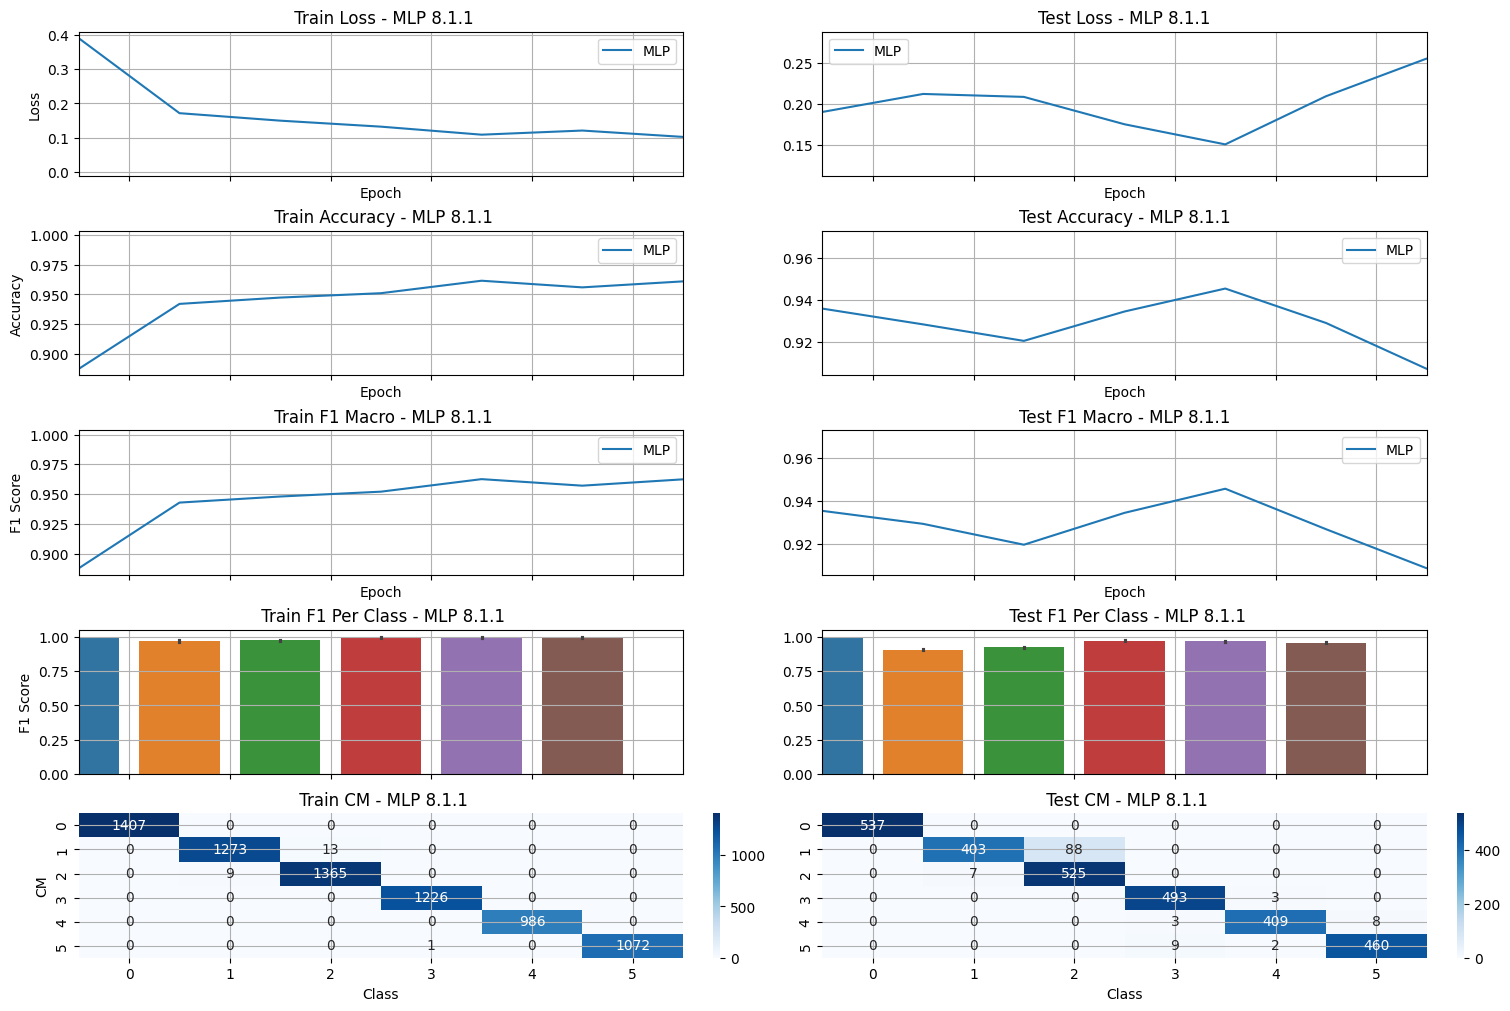

In [21]:
# --- Modèle 8.1.1 --
mlp_8_1_1= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU(), p_dropout=0.1)
mlp_8_1_1= mlp_8_1_1.to(device)
optimizer = torch.optim.Adam(mlp_8_1_1.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.1.1)")
history_mlp_8_1_1= compute_train_history(mlp_8_1_1, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_1_1, title_suffix=' MLP 8.1.1')

### 8.1.2 Dropout : 0.3

==> Entraînement du modèle MLP avec ReLU (Modèle 8.1.2)
Epoch 10/100 - Train Loss: 0.0987, Train Acc: 0.9686, Test Loss: 0.1445, Test Acc: 0.9525
Epoch 20/100 - Train Loss: 0.0787, Train Acc: 0.9733, Test Loss: 0.2702, Test Acc: 0.9257
Epoch 30/100 - Train Loss: 0.0643, Train Acc: 0.9777, Test Loss: 0.1169, Test Acc: 0.9647
Epoch 40/100 - Train Loss: 0.0543, Train Acc: 0.9826, Test Loss: 0.1765, Test Acc: 0.9542
Epoch 50/100 - Train Loss: 0.0280, Train Acc: 0.9905, Test Loss: 0.1678, Test Acc: 0.9562
Epoch 60/100 - Train Loss: 0.0278, Train Acc: 0.9908, Test Loss: 0.2745, Test Acc: 0.9389
Epoch 70/100 - Train Loss: 0.0280, Train Acc: 0.9902, Test Loss: 0.1677, Test Acc: 0.9610
Epoch 80/100 - Train Loss: 0.0206, Train Acc: 0.9924, Test Loss: 0.2409, Test Acc: 0.9450
Epoch 90/100 - Train Loss: 0.0241, Train Acc: 0.9910, Test Loss: 0.2205, Test Acc: 0.9545
Epoch 100/100 - Train Loss: 0.0132, Train Acc: 0.9946, Test Loss: 0.2074, Test Acc: 0.9596


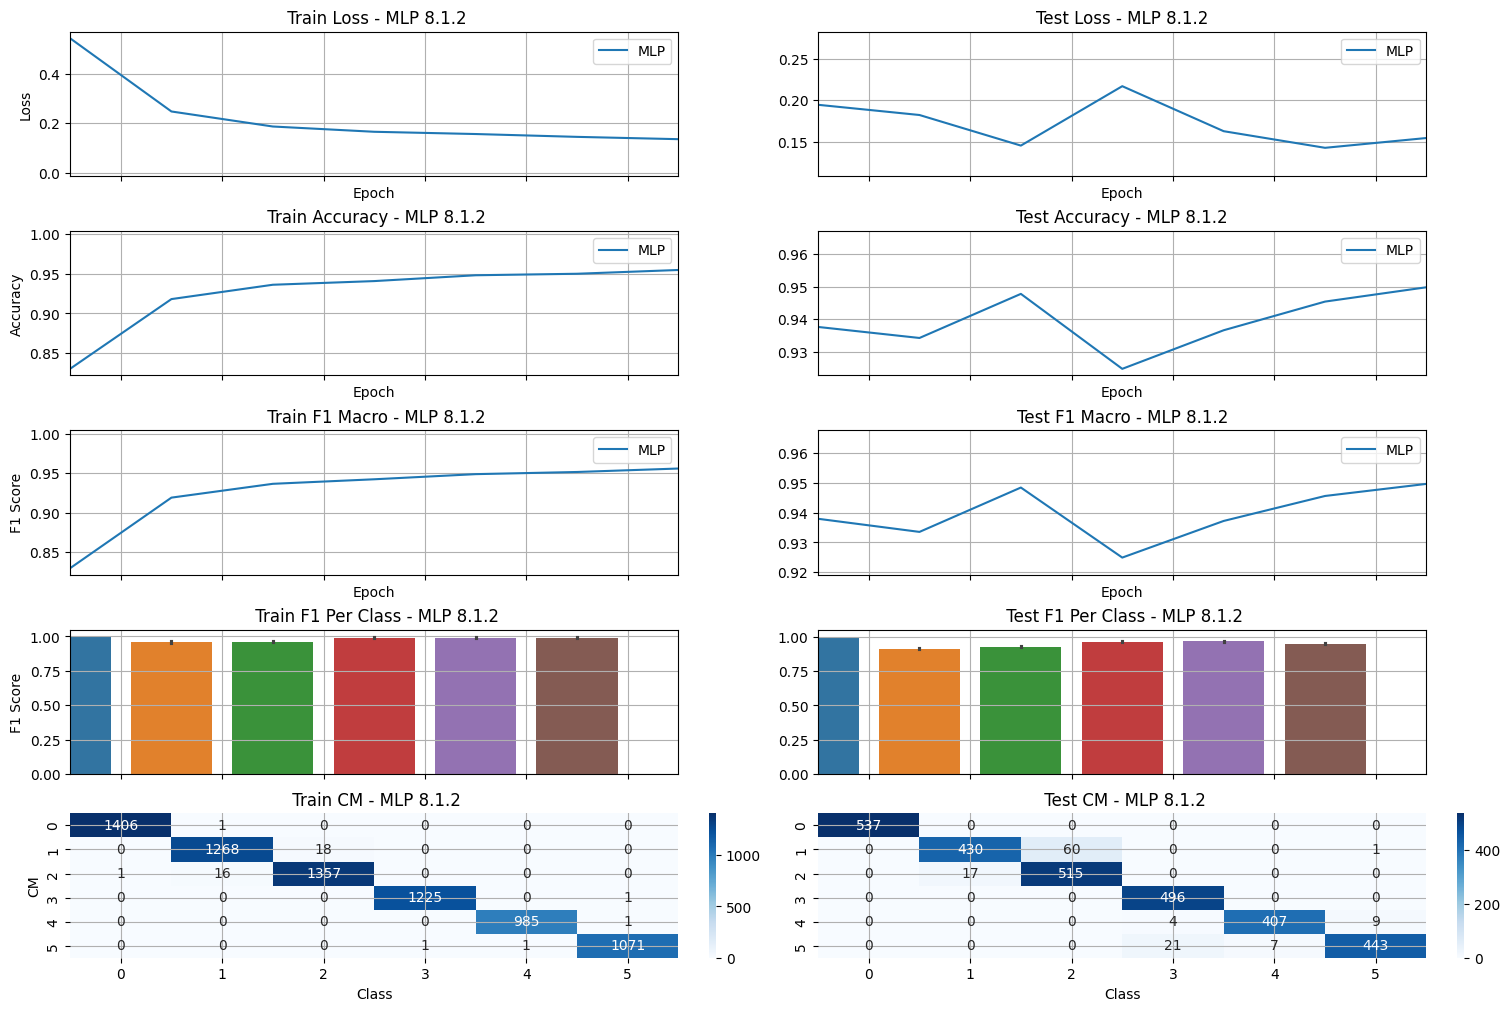

In [22]:
# --- Modèle 8.1.2 --
mlp_8_1_2= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU(), p_dropout=0.3)
mlp_8_1_2= mlp_8_1_2.to(device)
optimizer = torch.optim.Adam(mlp_8_1_2.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.1.2)")
history_mlp_8_1_2= compute_train_history(mlp_8_1_2, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_1_2, title_suffix=' MLP 8.1.2')

### 8.1.3 Dropout : 0.5

==> Entraînement du modèle MLP avec ReLU (Modèle 8.1.3)
Epoch 10/100 - Train Loss: 0.1708, Train Acc: 0.9452, Test Loss: 0.1895, Test Acc: 0.9264
Epoch 20/100 - Train Loss: 0.1178, Train Acc: 0.9607, Test Loss: 0.1563, Test Acc: 0.9505
Epoch 30/100 - Train Loss: 0.1078, Train Acc: 0.9634, Test Loss: 0.1483, Test Acc: 0.9539
Epoch 40/100 - Train Loss: 0.0776, Train Acc: 0.9737, Test Loss: 0.1256, Test Acc: 0.9630
Epoch 50/100 - Train Loss: 0.0675, Train Acc: 0.9769, Test Loss: 0.1526, Test Acc: 0.9528
Epoch 60/100 - Train Loss: 0.0526, Train Acc: 0.9811, Test Loss: 0.1565, Test Acc: 0.9610
Epoch 70/100 - Train Loss: 0.0548, Train Acc: 0.9835, Test Loss: 0.1933, Test Acc: 0.9552
Epoch 80/100 - Train Loss: 0.0550, Train Acc: 0.9819, Test Loss: 0.1471, Test Acc: 0.9634
Epoch 90/100 - Train Loss: 0.0448, Train Acc: 0.9846, Test Loss: 0.1610, Test Acc: 0.9583
Epoch 100/100 - Train Loss: 0.0395, Train Acc: 0.9876, Test Loss: 0.1614, Test Acc: 0.9640


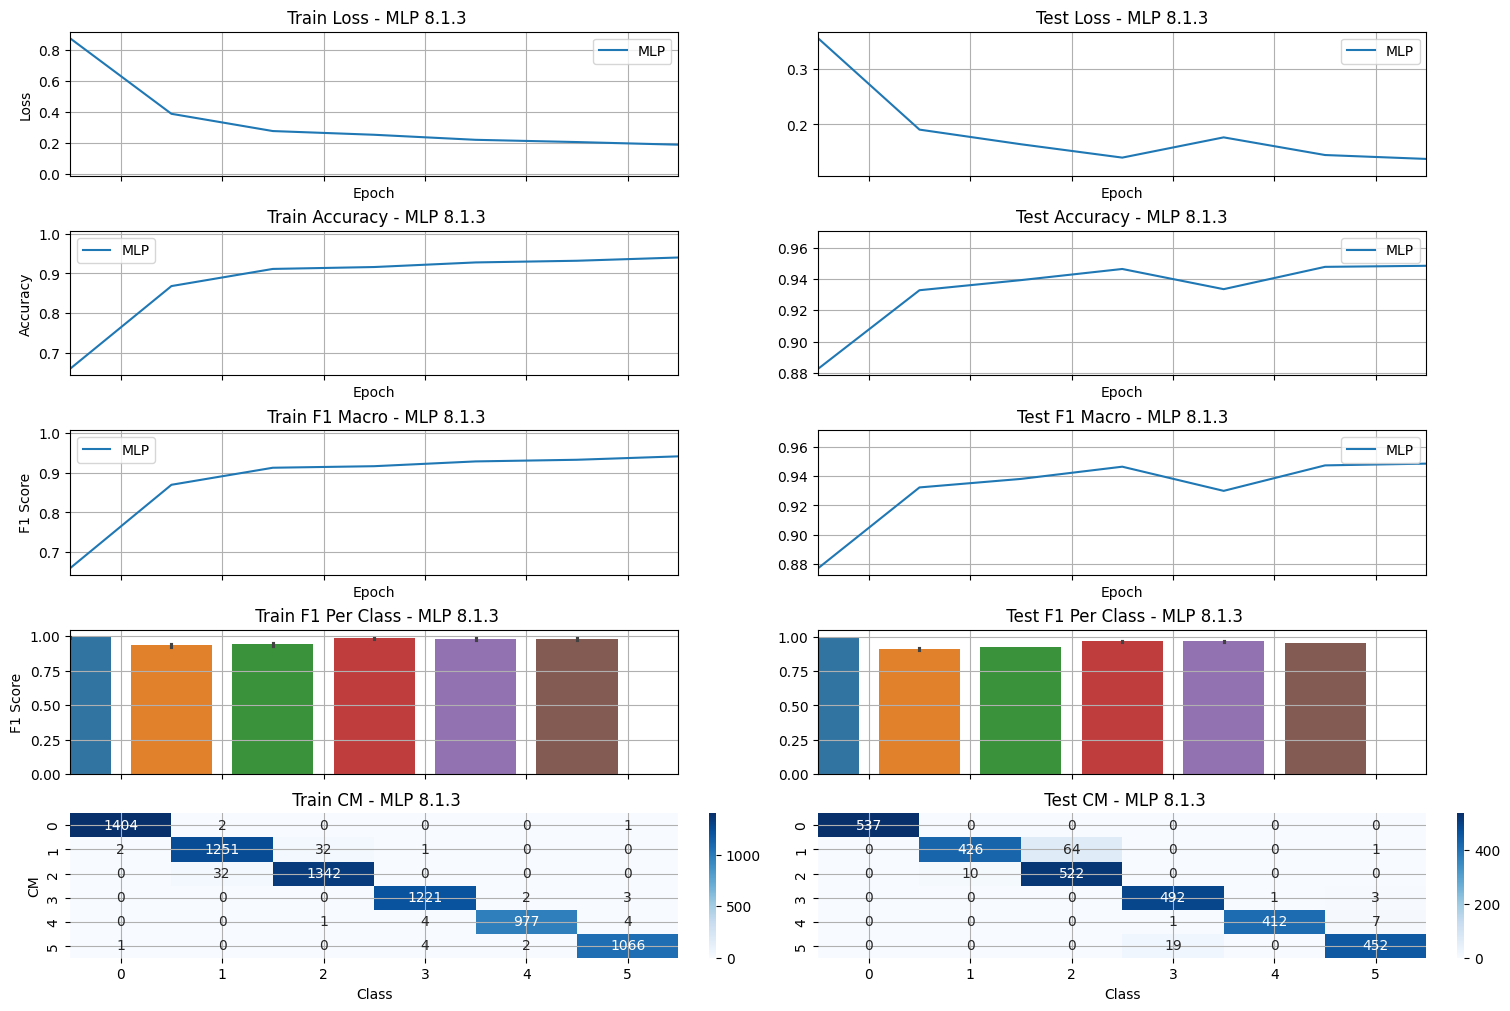

In [23]:
# --- Modèle 8.1.3 --
mlp_8_1_3= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU(), p_dropout=0.5)
mlp_8_1_3= mlp_8_1_3.to(device)
optimizer = torch.optim.Adam(mlp_8_1_3.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.1.3)")
history_mlp_8_1_3= compute_train_history(mlp_8_1_3, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_1_3, title_suffix=' MLP 8.1.3')

## 8.2 Weight Decay

### 8.2.1 Weight Decay : 1e-4

==> Entraînement du modèle MLP avec ReLU (Modèle 8.2.1)
Epoch 10/100 - Train Loss: 0.0890, Train Acc: 0.9675, Test Loss: 0.1680, Test Acc: 0.9460
Epoch 20/100 - Train Loss: 0.0499, Train Acc: 0.9807, Test Loss: 0.2022, Test Acc: 0.9410
Epoch 30/100 - Train Loss: 0.0503, Train Acc: 0.9816, Test Loss: 0.2427, Test Acc: 0.9281
Epoch 40/100 - Train Loss: 0.0445, Train Acc: 0.9856, Test Loss: 0.1877, Test Acc: 0.9471
Epoch 50/100 - Train Loss: 0.0261, Train Acc: 0.9921, Test Loss: 0.2146, Test Acc: 0.9440
Epoch 60/100 - Train Loss: 0.0226, Train Acc: 0.9918, Test Loss: 0.2390, Test Acc: 0.9430
Epoch 70/100 - Train Loss: 0.0259, Train Acc: 0.9918, Test Loss: 0.2545, Test Acc: 0.9416
Epoch 80/100 - Train Loss: 0.0219, Train Acc: 0.9927, Test Loss: 0.2159, Test Acc: 0.9464
Epoch 90/100 - Train Loss: 0.0108, Train Acc: 0.9961, Test Loss: 0.2025, Test Acc: 0.9498
Epoch 100/100 - Train Loss: 0.0155, Train Acc: 0.9943, Test Loss: 0.2242, Test Acc: 0.9518


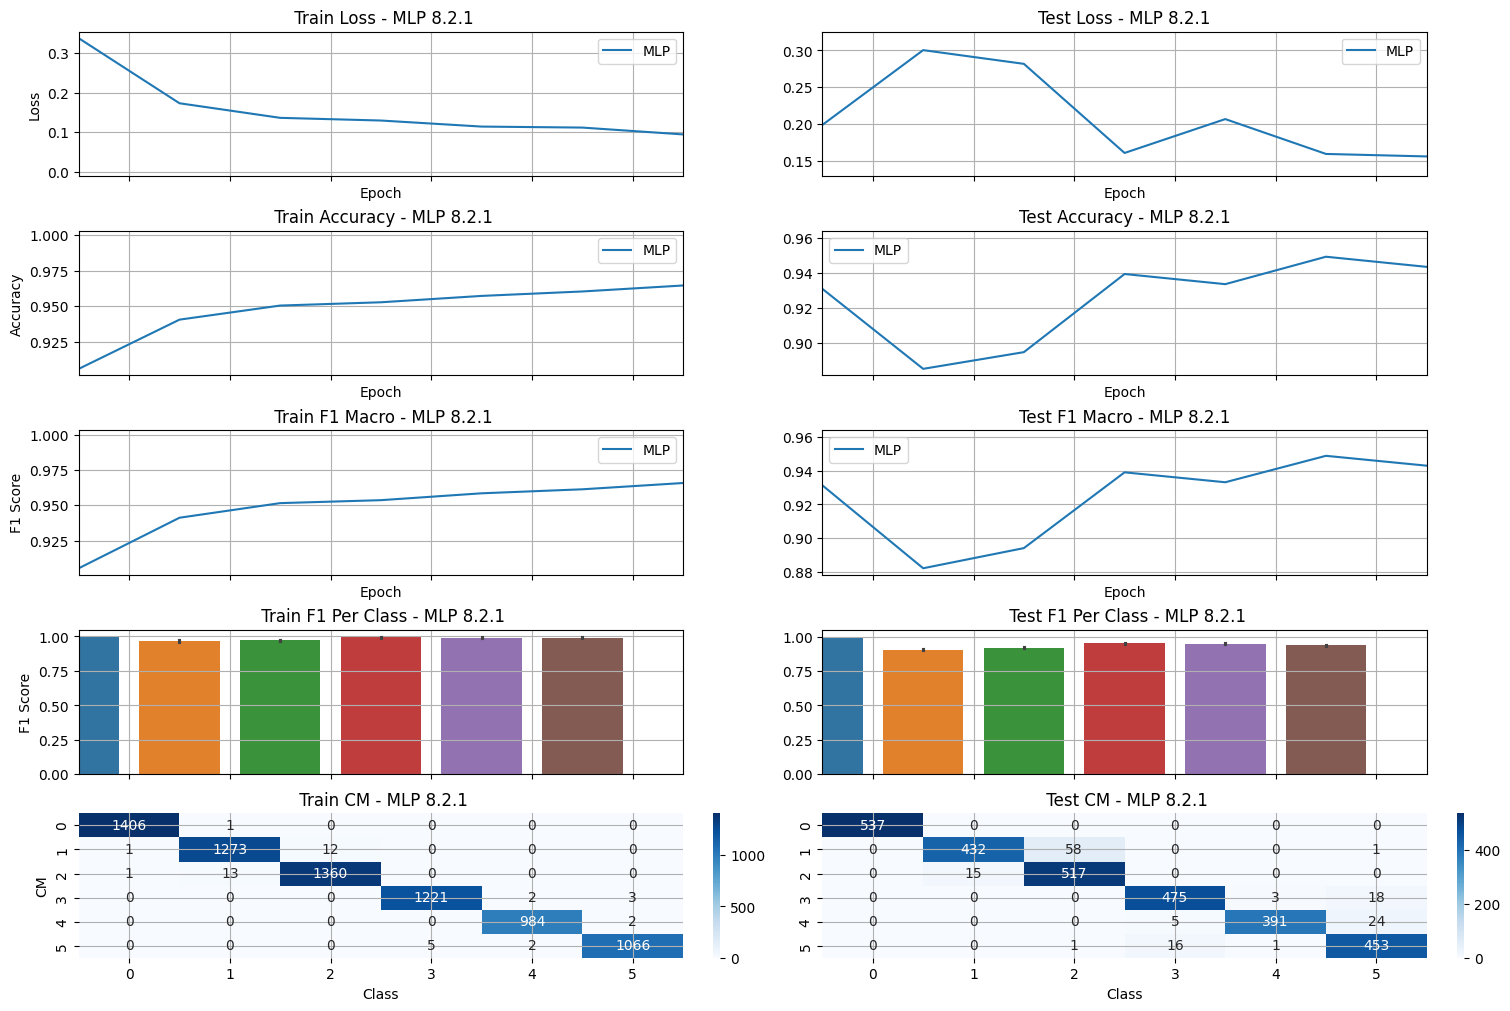

In [24]:
# --- Modèle 8.2.1 --
mlp_8_2_1= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_8_2_1 = mlp_8_2_1.to(device)
optimizer = torch.optim.Adam(mlp_8_2_1.parameters(), lr=CONFIG['LR'], weight_decay=1e-4)
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.2.1)")
history_mlp_8_2_1 = compute_train_history(mlp_8_2_1, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_2_1, title_suffix=' MLP 8.2.1')

### 8.2.2 Weight Decay : 1e-3

==> Entraînement du modèle MLP avec ReLU (Modèle 8.2.2)
Epoch 10/100 - Train Loss: 0.0934, Train Acc: 0.9653, Test Loss: 0.1448, Test Acc: 0.9505
Epoch 20/100 - Train Loss: 0.0803, Train Acc: 0.9717, Test Loss: 0.1991, Test Acc: 0.9399
Epoch 30/100 - Train Loss: 0.0436, Train Acc: 0.9854, Test Loss: 0.1521, Test Acc: 0.9494
Epoch 40/100 - Train Loss: 0.0421, Train Acc: 0.9863, Test Loss: 0.1755, Test Acc: 0.9460
Epoch 50/100 - Train Loss: 0.0419, Train Acc: 0.9879, Test Loss: 0.1711, Test Acc: 0.9539
Epoch 60/100 - Train Loss: 0.0630, Train Acc: 0.9789, Test Loss: 0.1870, Test Acc: 0.9430
Epoch 70/100 - Train Loss: 0.0259, Train Acc: 0.9918, Test Loss: 0.1888, Test Acc: 0.9467
Epoch 80/100 - Train Loss: 0.0370, Train Acc: 0.9874, Test Loss: 0.1664, Test Acc: 0.9498
Epoch 90/100 - Train Loss: 0.0242, Train Acc: 0.9933, Test Loss: 0.1748, Test Acc: 0.9501
Epoch 100/100 - Train Loss: 0.0250, Train Acc: 0.9936, Test Loss: 0.1876, Test Acc: 0.9471


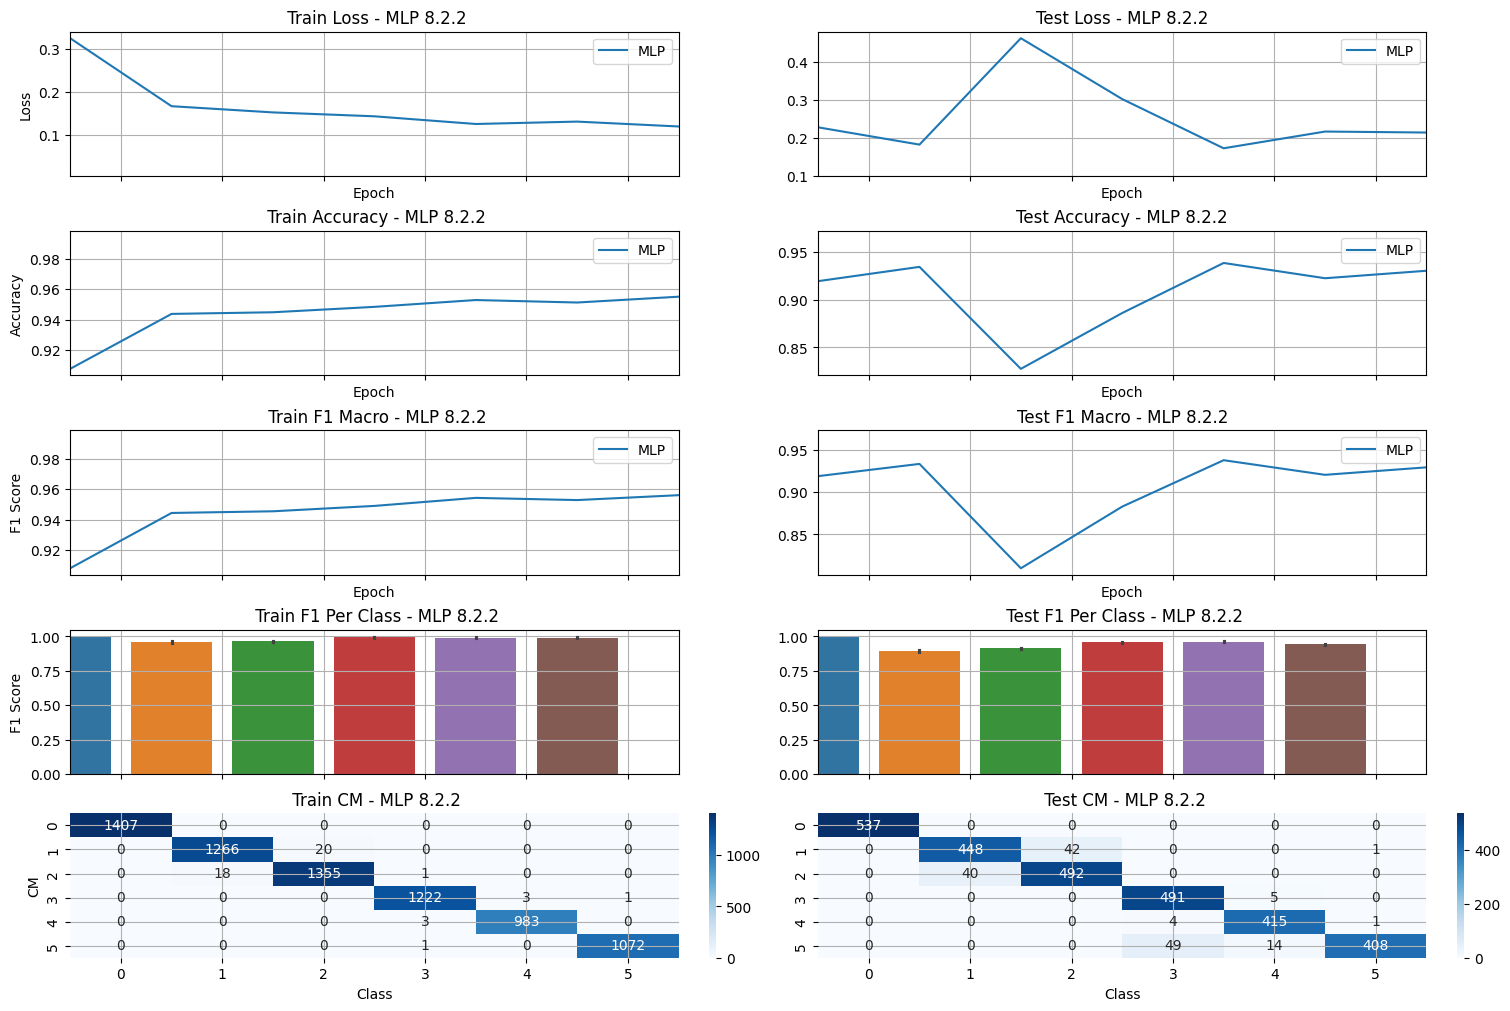

In [25]:
# --- Modèle 8.2.2 --
mlp_8_2_2= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_8_2_2 = mlp_8_2_2.to(device)
optimizer = torch.optim.Adam(mlp_8_2_2.parameters(), lr=CONFIG['LR'], weight_decay=1e-3)
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.2.2)")
history_mlp_8_2_2 = compute_train_history(mlp_8_2_2, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_2_2, title_suffix=' MLP 8.2.2')

### 8.2.3 Weight Decay : 1e-2

==> Entraînement du modèle MLP avec ReLU (Modèle 8.2.3)
Epoch 10/100 - Train Loss: 0.1518, Train Acc: 0.9580, Test Loss: 0.2415, Test Acc: 0.9260
Epoch 20/100 - Train Loss: 0.1000, Train Acc: 0.9754, Test Loss: 0.1988, Test Acc: 0.9359
Epoch 30/100 - Train Loss: 0.1198, Train Acc: 0.9686, Test Loss: 0.1380, Test Acc: 0.9583
Epoch 40/100 - Train Loss: 0.1181, Train Acc: 0.9691, Test Loss: 0.1439, Test Acc: 0.9583
Epoch 50/100 - Train Loss: 0.1013, Train Acc: 0.9747, Test Loss: 0.1679, Test Acc: 0.9515
Epoch 60/100 - Train Loss: 0.1039, Train Acc: 0.9742, Test Loss: 0.2343, Test Acc: 0.9369
Epoch 70/100 - Train Loss: 0.1021, Train Acc: 0.9742, Test Loss: 0.1937, Test Acc: 0.9488
Epoch 80/100 - Train Loss: 0.0987, Train Acc: 0.9725, Test Loss: 0.2336, Test Acc: 0.9294
Epoch 90/100 - Train Loss: 0.1192, Train Acc: 0.9650, Test Loss: 0.1455, Test Acc: 0.9559
Epoch 100/100 - Train Loss: 0.1015, Train Acc: 0.9718, Test Loss: 0.1638, Test Acc: 0.9552


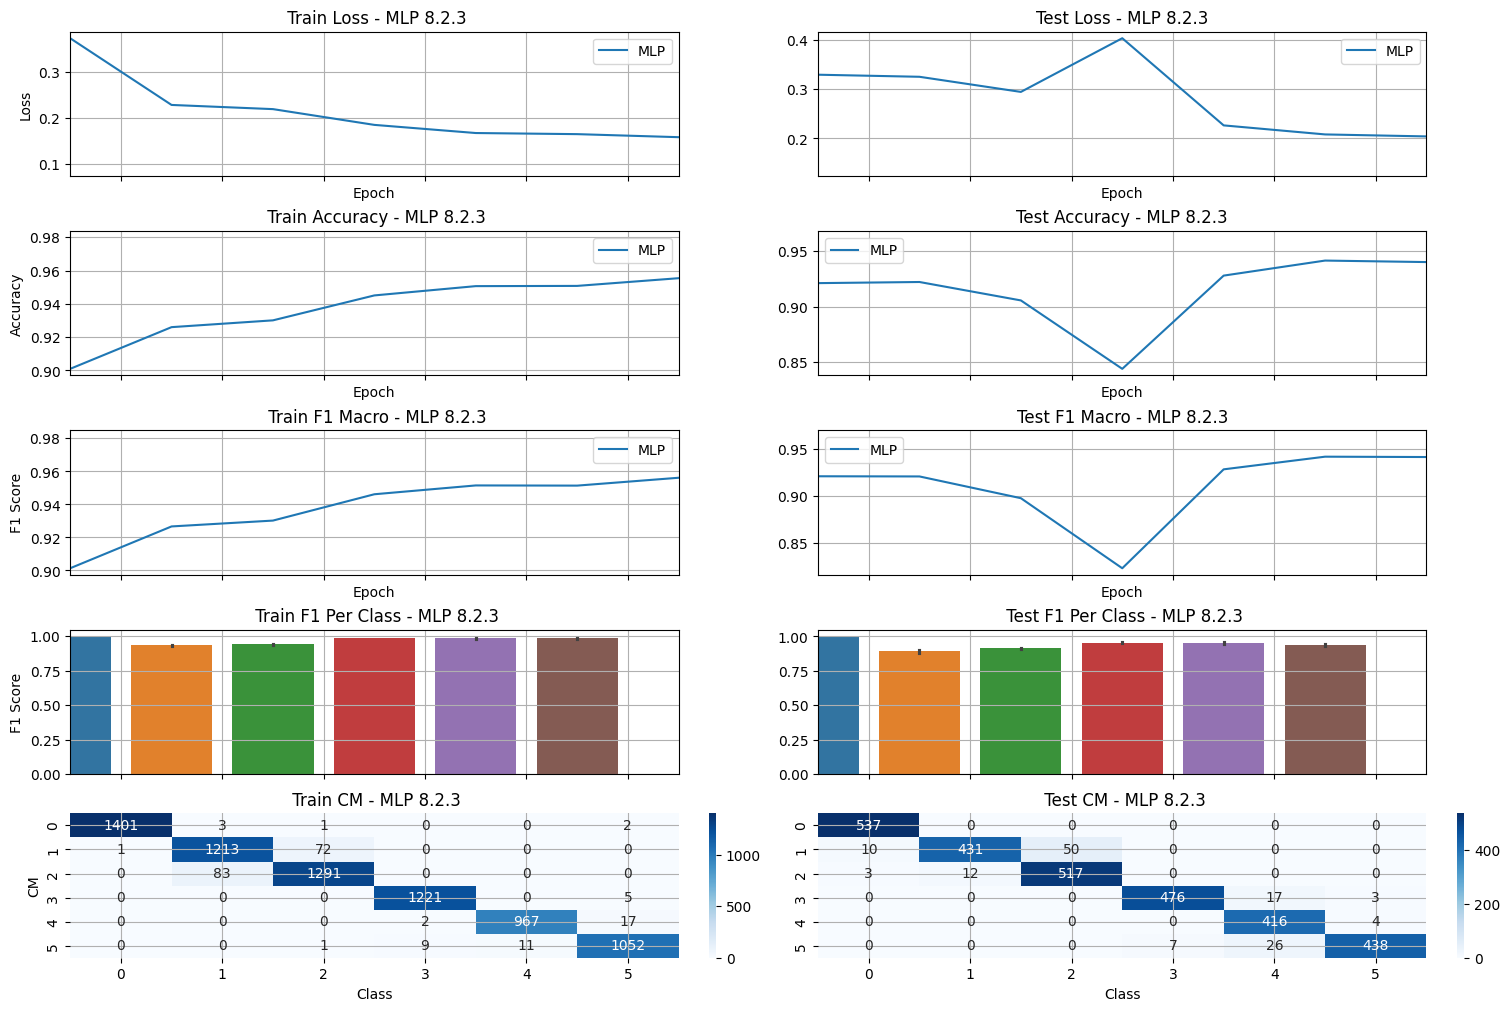

In [26]:
# --- Modèle 8.2.3 --
mlp_8_2_3= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_8_2_3 = mlp_8_2_3.to(device)
optimizer = torch.optim.Adam(mlp_8_2_3.parameters(), lr=CONFIG['LR'], weight_decay=1e-2)
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.2.3)")
history_mlp_8_2_3 = compute_train_history(mlp_8_2_3, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_2_3, title_suffix=' MLP 8.2.3')

## 8.3 Batch normalization

==> Entraînement du modèle MLP avec ReLU (Modèle 8.3)
Epoch 10/100 - Train Loss: 0.0824, Train Acc: 0.9684, Test Loss: 0.1223, Test Acc: 0.9596
Epoch 20/100 - Train Loss: 0.0449, Train Acc: 0.9829, Test Loss: 0.1728, Test Acc: 0.9498
Epoch 30/100 - Train Loss: 0.0401, Train Acc: 0.9865, Test Loss: 0.1932, Test Acc: 0.9511
Epoch 40/100 - Train Loss: 0.0323, Train Acc: 0.9890, Test Loss: 0.1387, Test Acc: 0.9678
Epoch 50/100 - Train Loss: 0.0132, Train Acc: 0.9955, Test Loss: 0.1625, Test Acc: 0.9596
Epoch 60/100 - Train Loss: 0.0130, Train Acc: 0.9954, Test Loss: 0.1833, Test Acc: 0.9583
Epoch 70/100 - Train Loss: 0.0095, Train Acc: 0.9966, Test Loss: 0.1490, Test Acc: 0.9644
Epoch 80/100 - Train Loss: 0.0101, Train Acc: 0.9959, Test Loss: 0.1599, Test Acc: 0.9634
Epoch 90/100 - Train Loss: 0.0120, Train Acc: 0.9966, Test Loss: 0.1897, Test Acc: 0.9525
Epoch 100/100 - Train Loss: 0.0218, Train Acc: 0.9922, Test Loss: 0.2067, Test Acc: 0.9555


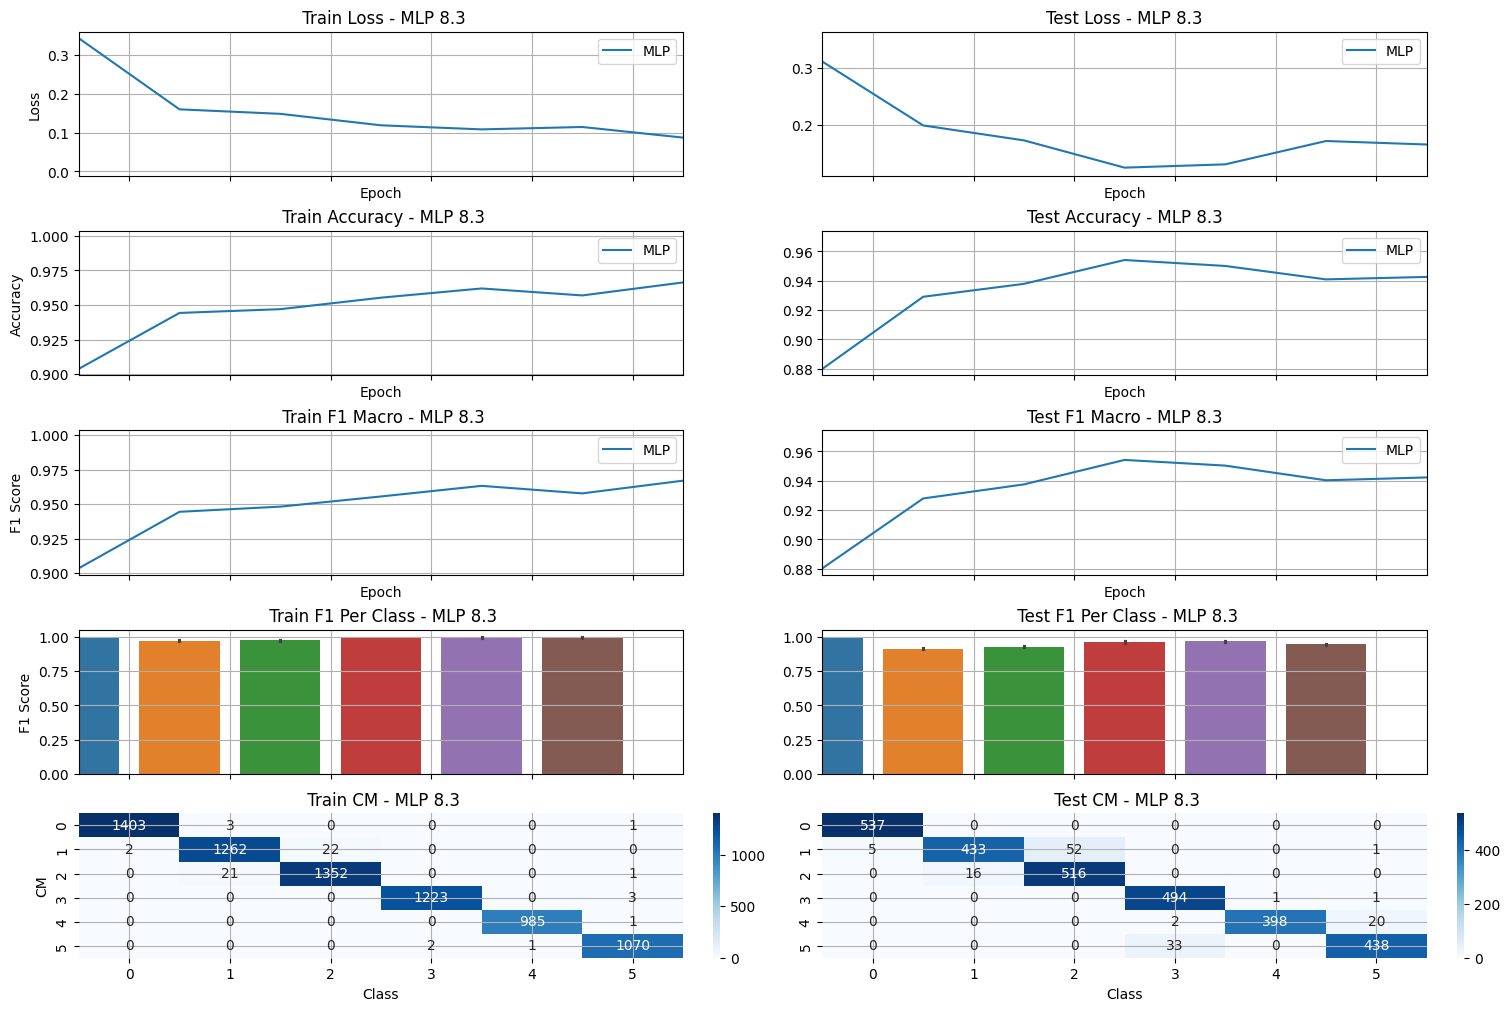

In [27]:
# --- Modèle 8.3 --
mlp_8_3= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU(), use_batchnorm=True)
mlp_8_3 = mlp_8_3.to(device)
optimizer = torch.optim.Adam(mlp_8_3.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.3)")
history_mlp_8_3 = compute_train_history(mlp_8_3, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_8_3, title_suffix=' MLP 8.3')

## 8.4 Early stopping

==> Entraînement du modèle MLP avec ReLU (Modèle 8.3)
Epoch 10/100 - Train Loss: 0.0732, Train Acc: 0.9725, Test Loss: 0.1274, Test Acc: 0.9593
Early stopping activé : l'entraînement s'arrête.


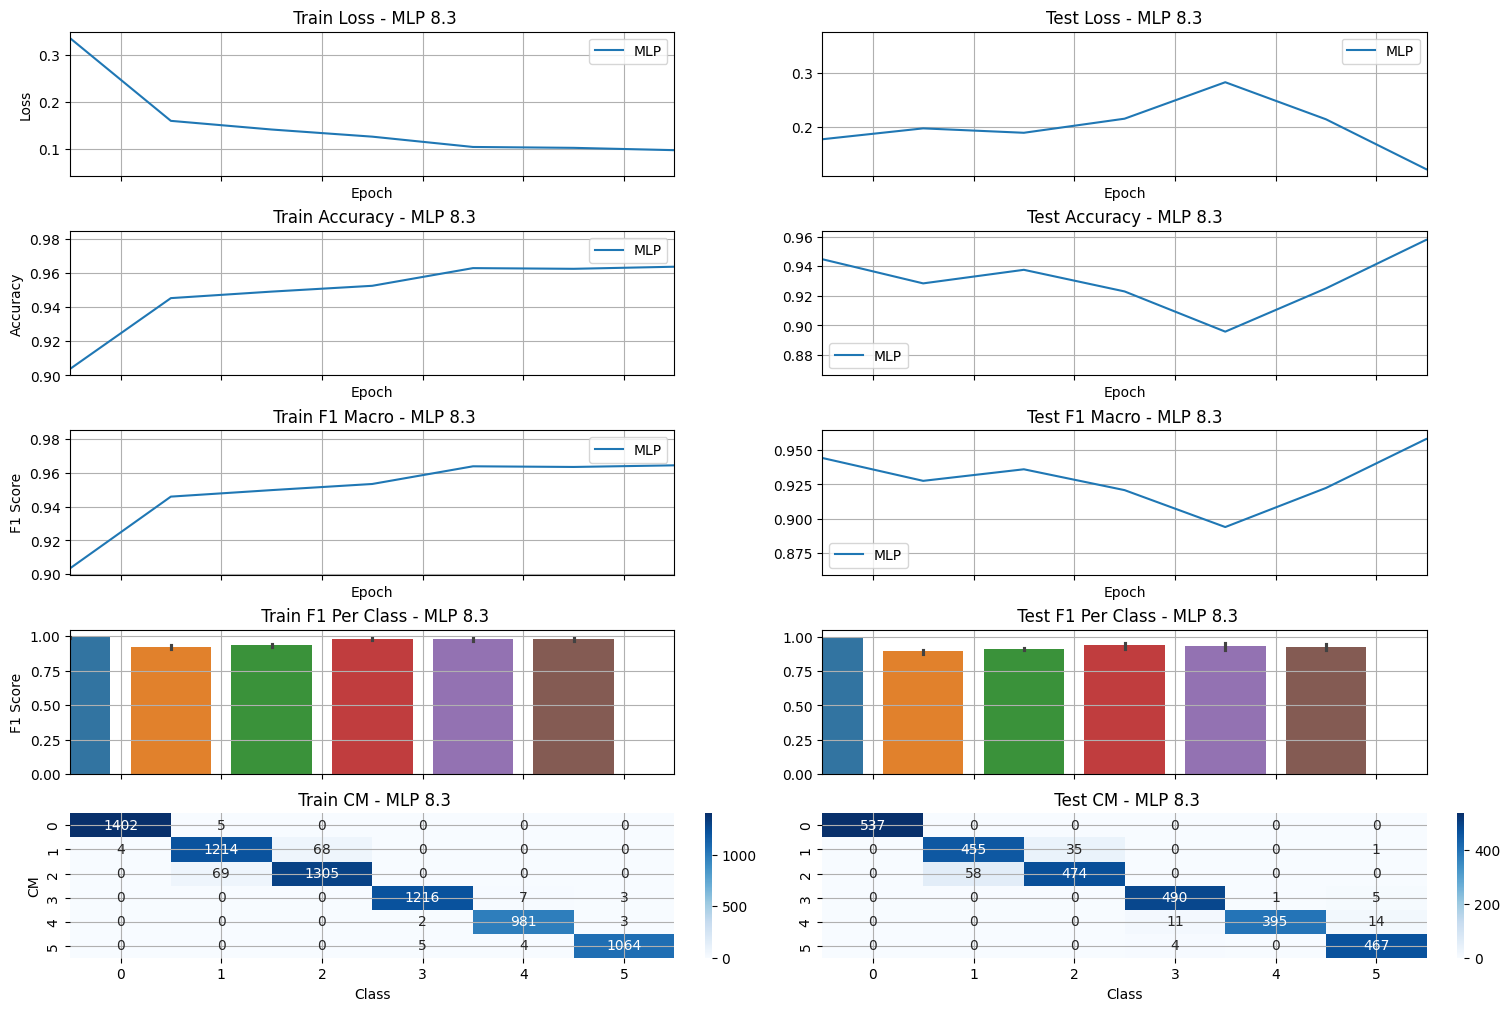

In [28]:
# --- Modèle 8.3 --
mlp_8_3= ActivityClassifier(input_dim=X_train.shape[1], hidden_dims=[512, 256, 128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_8_3 = mlp_8_3.to(device)
optimizer = torch.optim.Adam(mlp_8_3.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 8.3)")
history_mlp_8_3 = compute_train_history(mlp_8_3, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'], early_stopping=True)
plot_training_history(history_mlp_8_3, title_suffix=' MLP 8.3')

# 9. Réduction de dimension

## 9.1 Méthode t-SNE

In [30]:
"""
plt.figure(figsize=(12, 5))
fig, axes = plt.subplot(1, 2, figsize=(12, 8))
axes[0, 0].scatter(mlp_9_['train_X_umap'], mlp_9_['train_X_umap'][:, 1], c=all_labels, cmap='Spectral', s=5)
axes[0, 0].set_title('Train UMAP')

axes[0, 0].scatter(mlp_9_['test_X_umap'], mlp_9_['test_X_umap'][:, 1], c=all_labels, cmap='Spectral', s=5)
axes[0, 0].set_title(' Test UMAP')
"""

"\nplt.figure(figsize=(12, 5))\nfig, axes = plt.subplot(1, 2, figsize=(12, 8))\naxes[0, 0].scatter(mlp_9_['train_X_umap'], mlp_9_['train_X_umap'][:, 1], c=all_labels, cmap='Spectral', s=5)\naxes[0, 0].set_title('Train UMAP')\n\naxes[0, 0].scatter(mlp_9_['test_X_umap'], mlp_9_['test_X_umap'][:, 1], c=all_labels, cmap='Spectral', s=5)\naxes[0, 0].set_title(' Test UMAP')\n"

## 9.2 Méthode UMAP

In [31]:
"""
plt.figure(figsize=(12, 5))
fig, axes = plt.subplot(1, 2, figsize=(12, 8))
axes[0, 0].scatter(mlp_9_['train_X_embedded'], mlp_9_['train_X_embedded'][:, 1], c=all_labels, cmap='Spectral', s=5)
axes[0, 0].set_title('Train t-SNE')

axes[0, 0].scatter(mlp_9_['test_X_embedded'], mlp_9_['test_X_embedded'][:, 1], c=all_labels, cmap='Spectral', s=5)
axes[0, 0].set_title(' Test t-SNE')
"""

"\nplt.figure(figsize=(12, 5))\nfig, axes = plt.subplot(1, 2, figsize=(12, 8))\naxes[0, 0].scatter(mlp_9_['train_X_embedded'], mlp_9_['train_X_embedded'][:, 1], c=all_labels, cmap='Spectral', s=5)\naxes[0, 0].set_title('Train t-SNE')\n\naxes[0, 0].scatter(mlp_9_['test_X_embedded'], mlp_9_['test_X_embedded'][:, 1], c=all_labels, cmap='Spectral', s=5)\naxes[0, 0].set_title(' Test t-SNE')\n"

# 10. Ouverture: Layernorm

In [32]:
class ActivityClassifierLN(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, activation):
        super().__init__()
        self.layers = nn.ModuleList()
        self.lns = nn.ModuleList()
        
        prev_dim = input_dim
        for h in hidden_dims:
            self.layers.append(nn.Linear(prev_dim, h))
            self.lns.append(nn.LayerNorm(h))
            prev_dim = h
        
        self.output = nn.Linear(prev_dim, num_classes)
        self.activation = activation

    def forward(self, x):
        for fc, ln in zip(self.layers, self.lns):
            x = fc(x)
            x = ln(x)             # layer normalization
            x = self.activation(x)
        x = self.output(x)
        return x

==> Entraînement du modèle MLP 10.
Epoch 10/100 - Train Loss: 0.0225, Train Acc: 0.9913, Test Loss: 0.1842, Test Acc: 0.9471
Early stopping activé : l'entraînement s'arrête.


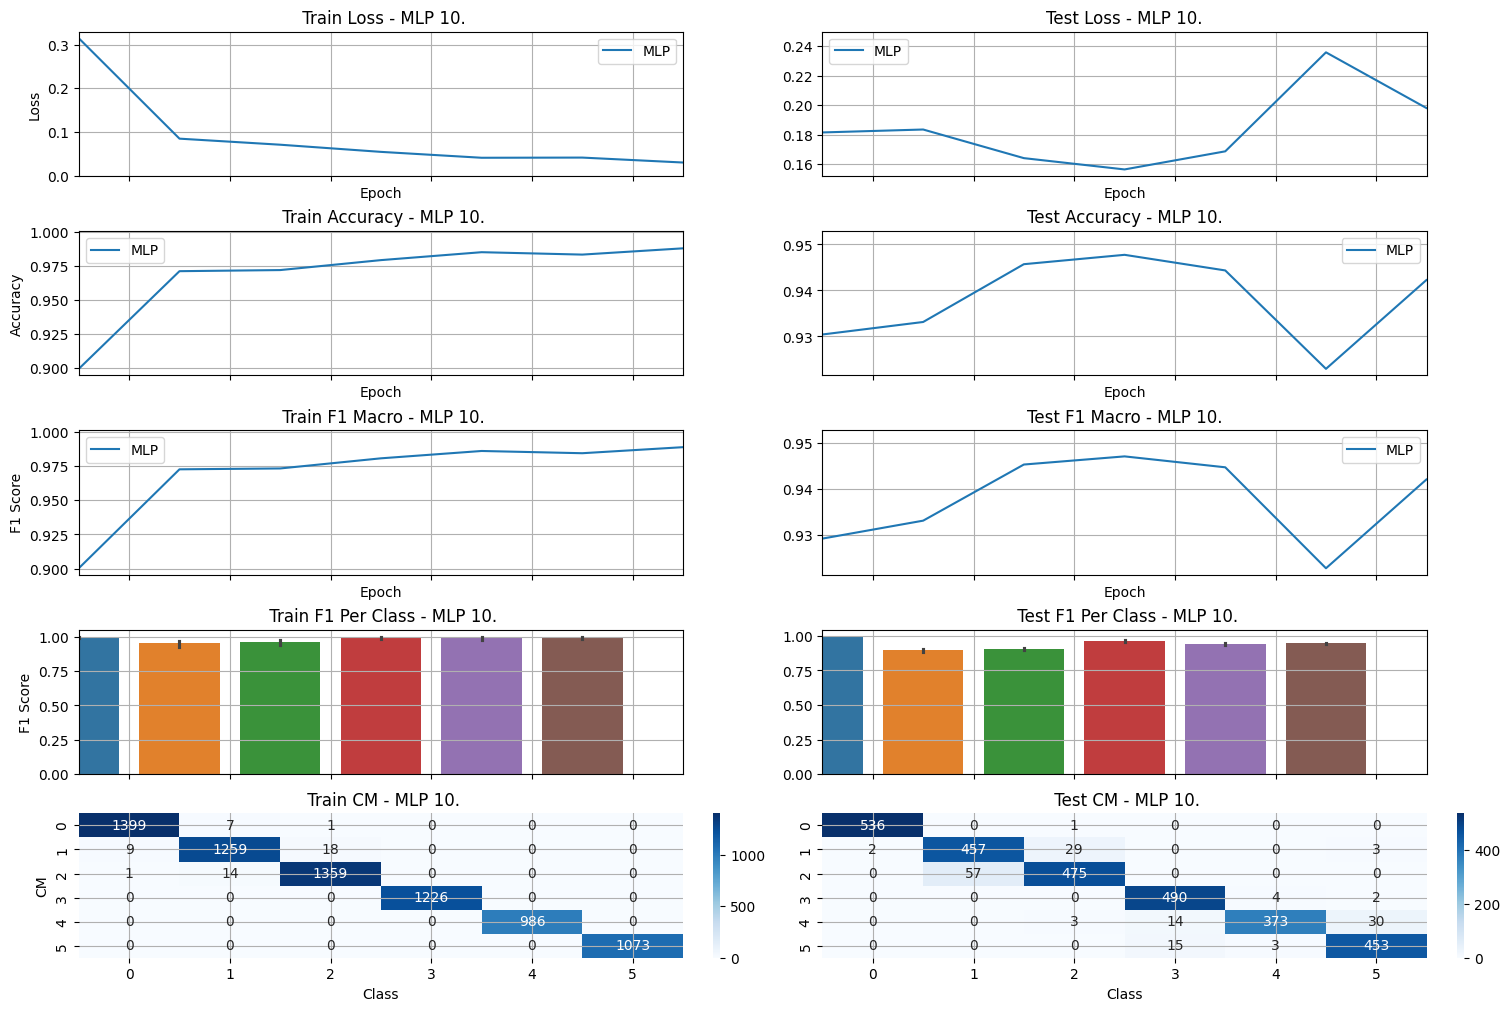

In [35]:
# --- Modèle 10. --
mlp_10= ActivityClassifierLN(input_dim=X_train.shape[1], hidden_dims=[128, 64], num_classes=len(le.classes_), activation=nn.ReLU())
mlp_10 = mlp_10.to(device)
optimizer = torch.optim.Adam(mlp_10.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()      
print("==> Entraînement du modèle MLP 10.")
history_mlp_10 = compute_train_history(mlp_10, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'], early_stopping=True)
plot_training_history(history_mlp_10, title_suffix=' MLP 10.')